# Laboratorio 1 — Exploración, preparación y regresión lineal

**Curso:** ISIS-2611 — Aprendizaje de Máquina  
**Caso:** AlpesPlanck  
**Integrantes:**  
- Daniel Vergara 202320392
- Julian Pinto 202321207

---

## Objetivo

Construir y evaluar modelos de regresión lineal para predecir la **temperatura máxima diaria**, identificar las variables meteorológicas que más aportan a la predicción y analizar posibles sesgos del proceso.


## Estructura del repositorio

```text
Lab1_ML/
├── Laboratorio_1.ipynb
├── Laboratorio_1.html
├── README.md
├── data/
│   ├── Datos Lab 1.csv
│   ├── Datos Test Lab 1.csv
│   └── Diccionario de datos.xlsx
└── resultados/
    └── Datos Test Lab 1.csv        # archivo base + columna temp_max_manana predicha
```

# 0. Configuración e importación de librerías

En esta sección se importan las librerías necesarias para:
- manipulación de datos,
- visualización,
- preparación,
- construcción de pipelines,
- regresión lineal,
- evaluación del modelo.

Agregar otras librerías únicamente si se necesitan y explicar para qué se usan.


In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Separación de datos
from sklearn.model_selection import train_test_split

# Preparación
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer

# Modelo
from sklearn.linear_model import LinearRegression
from sklearn.base import clone

# Métricas
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Verificación de supuestos de la regresión lineal
import scipy.sparse
import scipy.stats as stats
from scipy.stats import shapiro
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import linear_rainbow, het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

# Utilidades
from pathlib import Path

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [2]:
# Rutas relativas del proyecto
DATA_DIR = Path("data")
RESULTS_DIR = Path("resultados")
RESULTS_DIR.mkdir(exist_ok=True)

TRAIN_PATH = DATA_DIR / "Datos Lab 1.csv"
FINAL_TEST_PATH = DATA_DIR / "Datos Test Lab 1.csv"
DICTIONARY_PATH = DATA_DIR / "Diccionario de datos.xlsx"

print("Datos de entrenamiento:", TRAIN_PATH)
print("Datos finales sin etiqueta:", FINAL_TEST_PATH)


Datos de entrenamiento: data/Datos Lab 1.csv
Datos finales sin etiqueta: data/Datos Test Lab 1.csv


# 1. Entendimiento del problema y de los datos

## 1.1 Contexto


El Instituto AlpesPlanck registra variables meteorológicas en su estación de Jena, Alemania. A partir de estos datos se busca construir un modelo que permita predecir la temperatura máxima del día siguiente e identificar cuáles variables meteorológicas aportan más a esta predicción.

El problema corresponde a una tarea de **aprendizaje supervisado**, ya que el conjunto de entrenamiento contiene una variable objetivo conocida. Como esta variable es numérica continua, la tarea corresponde específicamente a un problema de **regresión**.

La variable objetivo del conjunto de datos es `temp_max_manana`, que representa la temperatura máxima que se quiere predecir para el día siguiente.

Cada registro representa la información meteorológica agregada de un día. Entre las variables disponibles se encuentran medidas relacionadas con presión atmosférica, humedad, viento, ráfagas, dirección del viento y variables temporales como año, mes y día del año.


## 1.2 Diccionario de datos

Revisar primero el archivo `Diccionario de datos.xlsx`.

**Aquí deben escribir un resumen de las variables relevantes y señalar cuál será la variable objetivo.**


In [3]:
# Cargar diccionario de datos
diccionario = pd.read_excel(DICTIONARY_PATH)
diccionario


,variable,tipo,descripcion
0,fecha,texto,"Fecha de la observación, en formato día.mes.año."
1,presion_media,numérico,Presión atmosférica media del día (mbar).
2,presion_min,numérico,Presión atmosférica mínima del día (mbar).
3,presion_max,numérico,Presión atmosférica máxima del día (mbar).
4,presion_desv,numérico,Desviación típica de la presión durante el día...
5,humedad_media,numérico,Humedad relativa media del día (%).
6,humedad_min,numérico,Humedad relativa mínima del día (%).
7,humedad_max,numérico,Humedad relativa máxima del día (%).
8,humedad_desv,numérico,Desviación típica de la humedad relativa (%).
9,viento_media,numérico,Velocidad media del viento durante el día (m/s).


### Análisis del diccionario

El diccionario de datos nos permite conocer el significado, tipo y unidad de las variables antes de hacer  el análisis. Este paso es importante para diferenciar el tipo técnico que Pandas detecta en cada columna del significado real de la variable.

A partir del diccionario y del contexto del laboratorio identificamos `temp_max_manana` como la variable objetivo. Las demás columnas corresponden a otras variables que describen las condiciones meteorológicas y características temporales de cada día.


# 2. Carga de datos


In [4]:
# Cargar datos de entrenamiento
data = pd.read_csv(TRAIN_PATH)

data.head()




,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,viento_max,viento_desv,rafaga_media,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.7786,0.05,1.559641,0.5753,1.3783,0.25,2.255577,0.8488,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S,-2.12
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.4195,0.22,3.870000,0.9168,2.2274,0.63,6.130000,1.2544,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE,-0.82
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.2509,0.12,3.640000,0.7299,2.0651,0.38,4.880000,0.9330,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO,-0.63
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.7204,0.54,2.454415,0.7023,3.5649,1.38,4.430375,1.1835,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO,-1.44
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.8003,1.00,7.810000,1.9521,5.9400,2.13,10.880000,NaN,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N,-10.88


In [5]:
print("Número de registros:", data.shape[0])
print("Número de variables:", data.shape[1])

print("\nColumnas:")
print(data.columns.tolist())

Número de registros: 2576
Número de variables: 27

Columnas:
['fecha', 'presion_media', 'presion_min', 'presion_max', 'presion_desv', 'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv', 'viento_media', 'viento_min', 'viento_max', 'viento_desv', 'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv', 'viento_norte', 'viento_este', 'direccion_viento', 'registros_del_dia', 'anio', 'dia_del_anio', 'estacion_anio', 'mes', 'sector_viento', 'temp_max_manana']


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2576 entries, 0 to 2575
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha              2504 non-null   object 
 1   presion_media      2501 non-null   float64
 2   presion_min        2502 non-null   float64
 3   presion_max        2512 non-null   float64
 4   presion_desv       2496 non-null   float64
 5   humedad_media      2502 non-null   float64
 6   humedad_min        2496 non-null   float64
 7   humedad_max        2490 non-null   float64
 8   humedad_desv       2515 non-null   float64
 9   viento_media       2490 non-null   float64
 10  viento_min         2485 non-null   float64
 11  viento_max         2495 non-null   float64
 12  viento_desv        2504 non-null   float64
 13  rafaga_media       2498 non-null   float64
 14  rafaga_min         2504 non-null   float64
 15  rafaga_max         2503 non-null   float64
 16  rafaga_desv        2497 

## 2.1 Observaciones iniciales

A partir de la estructura del conjunto de datos se observa que cada fila corresponde a un día y contiene diferentes medidas meteorológicas agregadas.

El conjunto incluye variables numéricas relacionadas con presión, humedad, viento y ráfagas; variables temporales como `fecha`, `anio`, `dia_del_anio` y `mes`. Variables categóricas como `estacion_anio` y `sector_viento` y la variable objetivo `temp_max_manana`.

En esta etapa todavía no se realizan correcciones. Primero se identificarán formalmente los posibles problemas de calidad durante el análisis exploratorio.


In [7]:
# Estadísticas descriptivas
data.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
fecha,2504,2486,2010-08-14,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
presion_media,2501.0,NaN,NaN,NaN,1010.494271,435.334494,948.996,984.2878,989.4528,994.469,9939.918
presion_min,2502.0,NaN,NaN,NaN,986.684409,8.927138,913.6,981.371333,987.07,992.5675,1012.320198
presion_max,2512.0,NaN,NaN,NaN,991.704244,7.726906,951.94,987.07,991.935,996.7825,1013.94
presion_desv,2496.0,NaN,NaN,NaN,1.752041,1.215931,0.2269,0.89905,1.44455,2.2548,12.3975
humedad_media,2502.0,NaN,NaN,NaN,52.413586,35.975384,0.004663,0.86906,68.5581,80.5626,100.0
humedad_min,2496.0,NaN,NaN,NaN,45.094067,30.196163,0.2377,1.01179,49.67,67.665,103.311405
humedad_max,2490.0,NaN,NaN,NaN,90.236582,10.647237,27.02,88.025,93.3,96.6,100.0
humedad_desv,2515.0,NaN,NaN,NaN,10.606821,5.481338,0.0,6.0821,10.1998,14.7222,26.3416
viento_media,2490.0,NaN,NaN,NaN,3.814103,3.307402,0.0,1.65535,2.4634,4.880505,24.7536


# 3. Exploración de datos (EDA)

1. Tipos de variables
2. Comportamiento general de las variables
3. Completitud
4.  Unicidad
5.  Consistencia
6.  Validez
7. Relación entre variables
8. Conclusiones del EDA


## 3.1 Tipos de variables


In [8]:
data.dtypes


fecha                 object
presion_media        float64
presion_min          float64
presion_max          float64
presion_desv         float64
humedad_media        float64
humedad_min          float64
humedad_max          float64
humedad_desv         float64
viento_media         float64
viento_min           float64
viento_max           float64
viento_desv          float64
rafaga_media         float64
rafaga_min           float64
rafaga_max           float64
rafaga_desv          float64
viento_norte         float64
viento_este          float64
direccion_viento     float64
registros_del_dia    float64
anio                 float64
dia_del_anio         float64
estacion_anio         object
mes                   object
sector_viento         object
temp_max_manana      float64
dtype: object

In [9]:

columnas_numericas = data.select_dtypes(include=np.number).columns.tolist()
columnas_no_numericas = data.select_dtypes(exclude=np.number).columns.tolist()

print("Variables numéricas:")
print(columnas_numericas)

print("\nVariables no numéricas:")
print(columnas_no_numericas)

Variables numéricas:
['presion_media', 'presion_min', 'presion_max', 'presion_desv', 'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv', 'viento_media', 'viento_min', 'viento_max', 'viento_desv', 'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv', 'viento_norte', 'viento_este', 'direccion_viento', 'registros_del_dia', 'anio', 'dia_del_anio', 'temp_max_manana']

Variables no numéricas:
['fecha', 'estacion_anio', 'mes', 'sector_viento']


### Análisis de los tipos de variables

Los tipos técnicos detectados por Pandas deben compararse con el significado de las variables descrito en el diccionario de datos.

Por ahora no se realizarán transformaciones solamente se identifican estas características para utilizarlas después durante la preparación de los datos.

## 3.2 Comportamiento de las variables
### Variables numéricas



In [10]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
presion_media,2501.0,1010.494271,435.334494,948.996000,984.287800,989.452800,994.469000,9939.918000
presion_min,2502.0,986.684409,8.927138,913.600000,981.371333,987.070000,992.567500,1012.320198
presion_max,2512.0,991.704244,7.726906,951.940000,987.070000,991.935000,996.782500,1013.940000
presion_desv,2496.0,1.752041,1.215931,0.226900,0.899050,1.444550,2.254800,12.397500
humedad_media,2502.0,52.413586,35.975384,0.004663,0.869060,68.558100,80.562600,100.000000
humedad_min,2496.0,45.094067,30.196163,0.237700,1.011790,49.670000,67.665000,103.311405
humedad_max,2490.0,90.236582,10.647237,27.020000,88.025000,93.300000,96.600000,100.000000
humedad_desv,2515.0,10.606821,5.481338,0.000000,6.082100,10.199800,14.722200,26.341600
viento_media,2490.0,3.814103,3.307402,0.000000,1.655350,2.463400,4.880505,24.753600
viento_min,2485.0,1.417799,3.960650,0.000000,0.230000,0.440000,0.960000,45.184956


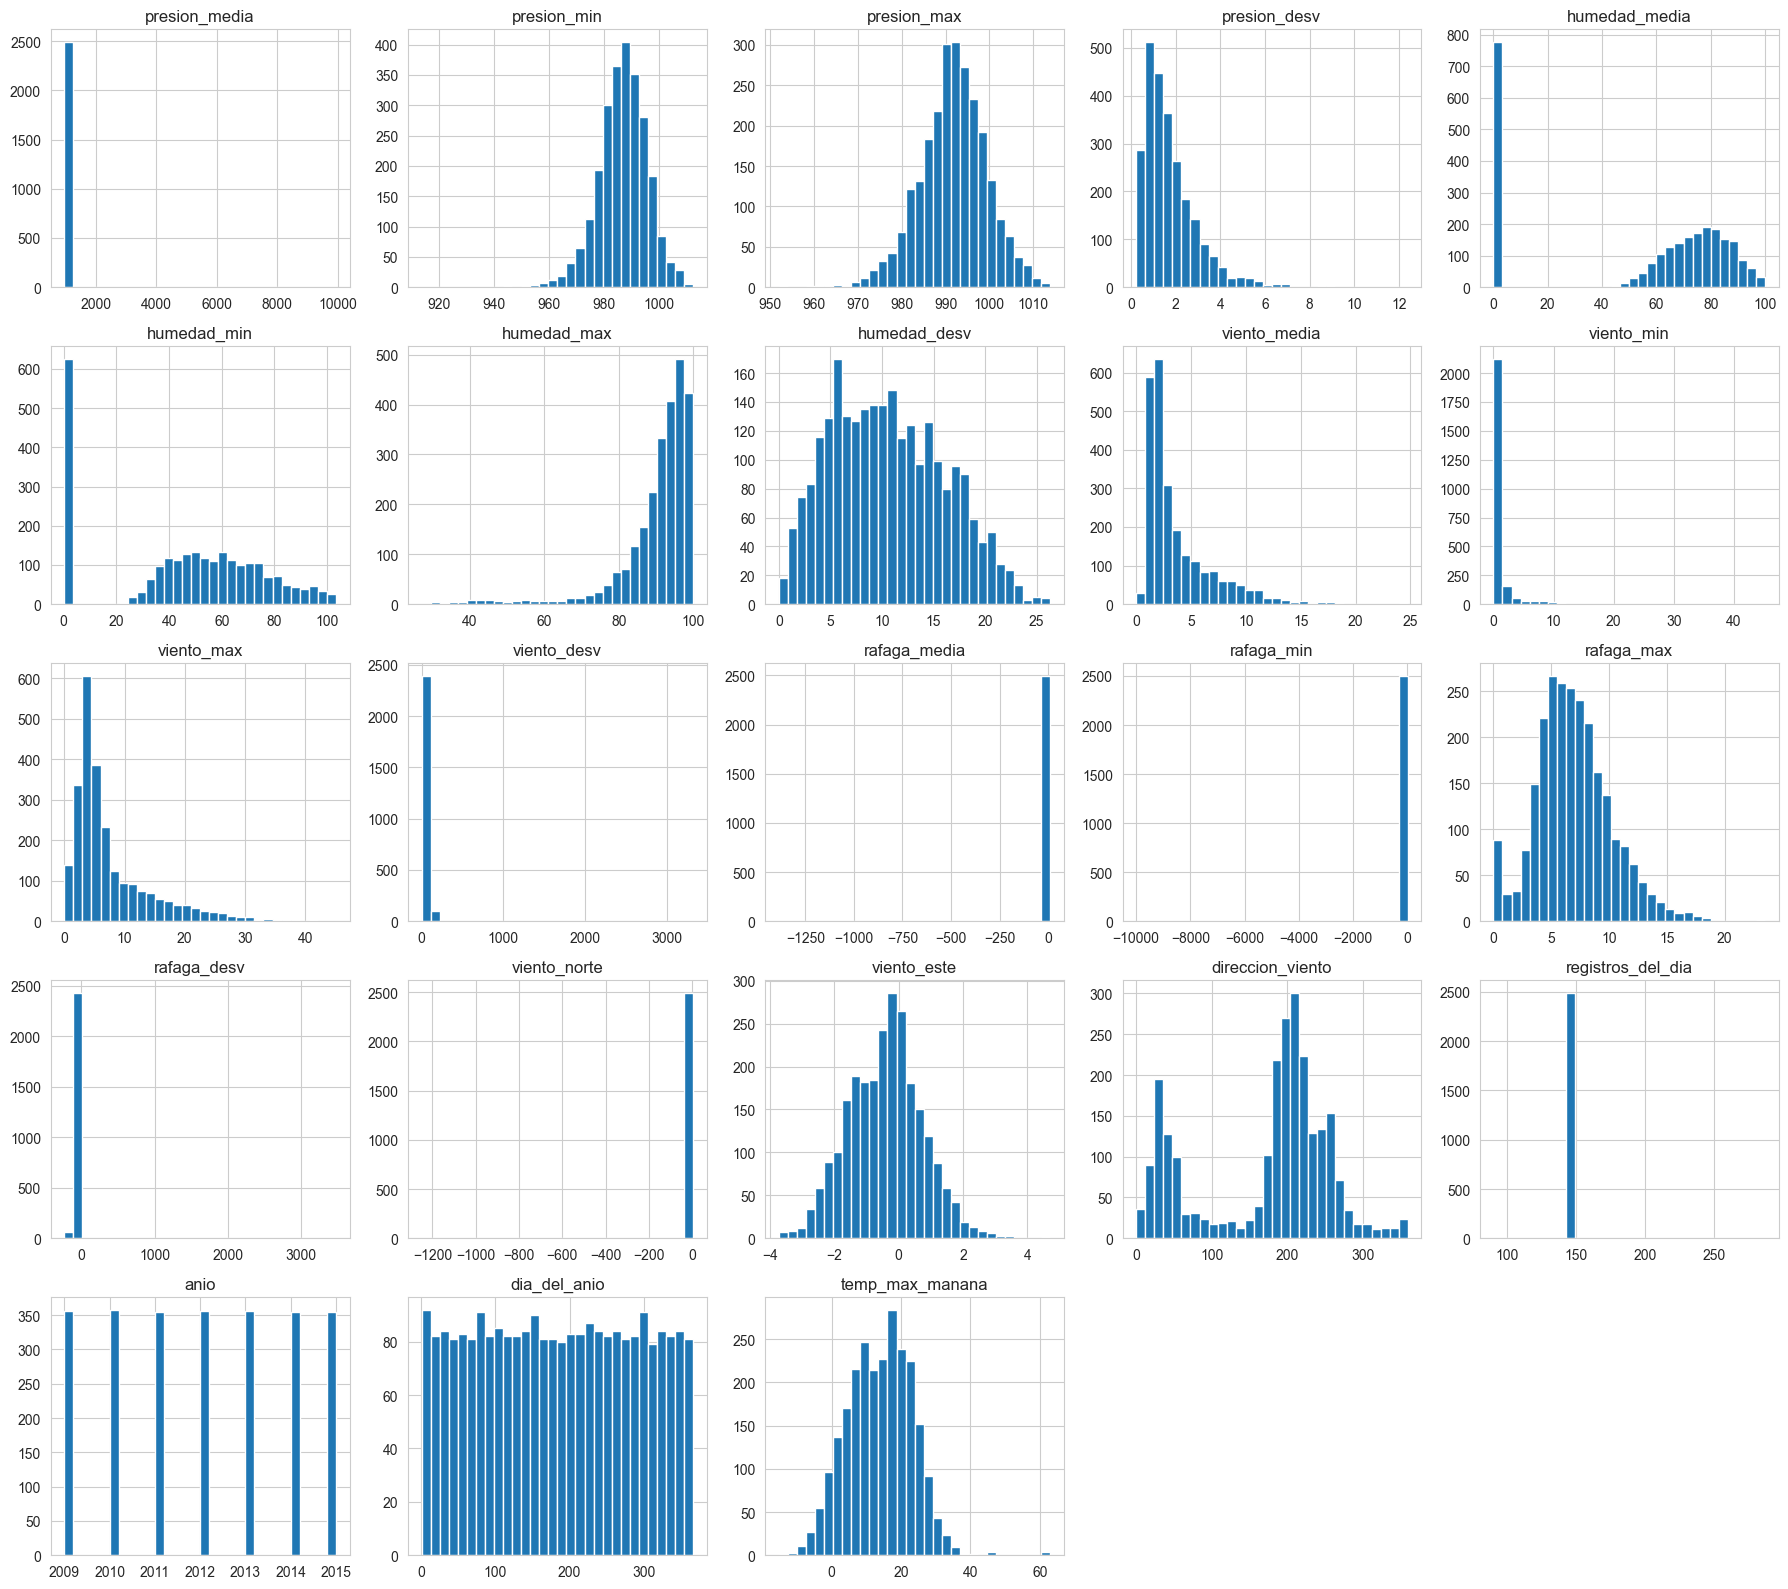

In [11]:
data[columnas_numericas].hist(
    figsize=(18, 16),
    bins=30
)

plt.tight_layout()
plt.show()

### Variables categóricas

In [12]:
for columna in columnas_no_numericas:
    print(f"\n--- {columna} ---")
    print(data[columna].value_counts(dropna=False))


--- fecha ---
fecha
NaN           72
2010-10-25     2
2009-05-02     2
2015-12-07     2
2009-03-05     2
              ..
2011-05-03     1
2011-05-04     1
2011-05-05     1
2011-05-06     1
2014-12-05     1
Name: count, Length: 2487, dtype: int64

--- estacion_anio ---
estacion_anio
primavera               517
invierno                511
otono                   500
verano                  487
NaN                      88
Inverano                 71
Estacion_Desconocida     63
VERANO_INVIERNO          60
East                     48
VERANO                   19
autumn                   18
primaveraa               17
berano                   17
fall                     15
winter                   15
verno                    14
Otoño                    12
otoño                    11
invernio                 11
PRIMAVERA                10
Primavera                10
Verano                    9
INVIERNO                  9
invierno                  9
Invierno                  9
OTONO          

## 3.3 Completitud


In [13]:
# Cantidad de datos faltantes por variable
data.isnull().sum().sort_values(ascending=False)


temp_max_manana      95
viento_min           91
mes                  88
estacion_anio        88
anio                 86
humedad_max          86
viento_media         86
viento_max           81
presion_desv         80
humedad_min          80
viento_norte         80
rafaga_desv          79
direccion_viento     79
rafaga_media         78
registros_del_dia    77
presion_media        75
humedad_media        74
presion_min          74
rafaga_max           73
rafaga_min           72
viento_desv          72
fecha                72
sector_viento        71
dia_del_anio         68
viento_este          64
presion_max          64
humedad_desv         61
dtype: int64

In [14]:
# Proporción de datos faltantes por variable
porcentaje_faltantes = (
    data.isnull().sum() / data.shape[0] * 100
).sort_values(ascending=False)

porcentaje_faltantes

temp_max_manana      3.687888
viento_min           3.532609
mes                  3.416149
estacion_anio        3.416149
anio                 3.338509
humedad_max          3.338509
viento_media         3.338509
viento_max           3.144410
presion_desv         3.105590
humedad_min          3.105590
viento_norte         3.105590
rafaga_desv          3.066770
direccion_viento     3.066770
rafaga_media         3.027950
registros_del_dia    2.989130
presion_media        2.911491
humedad_media        2.872671
presion_min          2.872671
rafaga_max           2.833851
rafaga_min           2.795031
viento_desv          2.795031
fecha                2.795031
sector_viento        2.756211
dia_del_anio         2.639752
viento_este          2.484472
presion_max          2.484472
humedad_desv         2.368012
dtype: float64

### Análisis de completitud

Se identificaron valores faltantes en algunas de las variables del conjunto de datos.

Las variables con mayor porcentaje de datos faltantes fueron `temp_max_manana`, `viento_min` y `estacion_anio `, con aproximadamente `3.68%`, `3.53%` y `3.41%` respectivamente.

## 3.4 Unicidad


In [15]:
# Número de filas completamente duplicadas
duplicados = data.duplicated(keep=False).sum()

print("Número de registros involucrados en duplicados:", duplicados)

Número de registros involucrados en duplicados: 8


In [16]:
# Ver las filas duplicadas
data[data.duplicated(keep=False)]

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,viento_max,viento_desv,rafaga_media,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
21,2009-01-22,9784.1150,971.48,983.54,3.9853,86.731100,69.11,97.6,9.7926,10.09692,1.440,26.532,178.43,4.2533,0.88,10.13,-122.650,-2.7229,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770
1412,2012-11-13,1005.3724,1002.77,1006.81,1.0690,88.175500,58.28,99.1,12.6853,4.07916,0.792,9.576,48.94,1.8189,0.40,3.80,-32.660,-0.9230,-0.2193,193.3681,144.0,2012.0,318.0,otono,abril,S,44.852
1499,2013-02-08,984.6369,983.06,987.49,1.3454,0.886056,0.76,96.8,4.6160,NaN,0.648,10.656,50.07,1.5029,0.52,5.01,-36.085,0.0254,-0.2613,275.5529,144.0,2013.0,39.0,verano,Sep,O,-0.600
1570,2013-04-20,1000.4455,998.46,1002.49,1.1632,60.748100,45.71,82.0,10.9518,17.65908,7.380,23.544,77.24,7.1450,3.72,9.41,-54.325,4.1573,2.5121,31.1426,144.0,2013.0,110.0,primavera,JANUARY,NE,61.412
2556,2013-04-20,1000.4455,998.46,1002.49,1.1632,60.748100,45.71,82.0,10.9518,17.65908,7.380,23.544,77.24,7.1450,3.72,9.41,-54.325,4.1573,2.5121,31.1426,144.0,2013.0,110.0,primavera,JANUARY,NE,61.412
2559,2012-11-13,1005.3724,1002.77,1006.81,1.0690,88.175500,58.28,99.1,12.6853,4.07916,0.792,9.576,48.94,1.8189,0.40,3.80,-32.660,-0.9230,-0.2193,193.3681,144.0,2012.0,318.0,otono,abril,S,44.852
2563,2009-01-22,9784.1150,971.48,983.54,3.9853,86.731100,69.11,97.6,9.7926,10.09692,1.440,26.532,178.43,4.2533,0.88,10.13,-122.650,-2.7229,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770
2565,2013-02-08,984.6369,983.06,987.49,1.3454,0.886056,0.76,96.8,4.6160,NaN,0.648,10.656,50.07,1.5029,0.52,5.01,-36.085,0.0254,-0.2613,275.5529,144.0,2013.0,39.0,verano,Sep,O,-0.600


## 3.5 Consistencia  


In [17]:
columnas_categoricas = [
    col for col in columnas_no_numericas
    if col != "fecha"
]

for columna in columnas_categoricas:
    print(f"\nVariable: {columna}")
    print(data[columna].value_counts(dropna=False))


Variable: estacion_anio
estacion_anio
primavera               517
invierno                511
otono                   500
verano                  487
NaN                      88
Inverano                 71
Estacion_Desconocida     63
VERANO_INVIERNO          60
East                     48
VERANO                   19
autumn                   18
primaveraa               17
berano                   17
fall                     15
winter                   15
verno                    14
Otoño                    12
otoño                    11
invernio                 11
PRIMAVERA                10
Primavera                10
Verano                    9
INVIERNO                  9
invierno                  9
Invierno                  9
OTONO                     8
primav                    6
spring                    6
summer                    6
Name: count, dtype: int64

Variable: mes
mes
May           127
August        125
July          123
January       120
March         118
             .

### Análisis de consistencia

La consistencia busca verificar que los valores que representan un mismo concepto se encuentren registrados de la misma manera.

Para las variables categóricas se revisaron sus categorías y frecuencias mediante `value_counts()`. Esto permite detectar posibles diferencias de formato, como el uso inconsistente de mayúsculas y minúsculas o valores que podrían corresponder a categorías incorrectas.


## 3.6 Validez

In [18]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
presion_media,2501.0,1010.494271,435.334494,948.996000,984.287800,989.452800,994.469000,9939.918000
presion_min,2502.0,986.684409,8.927138,913.600000,981.371333,987.070000,992.567500,1012.320198
presion_max,2512.0,991.704244,7.726906,951.940000,987.070000,991.935000,996.782500,1013.940000
presion_desv,2496.0,1.752041,1.215931,0.226900,0.899050,1.444550,2.254800,12.397500
humedad_media,2502.0,52.413586,35.975384,0.004663,0.869060,68.558100,80.562600,100.000000
humedad_min,2496.0,45.094067,30.196163,0.237700,1.011790,49.670000,67.665000,103.311405
humedad_max,2490.0,90.236582,10.647237,27.020000,88.025000,93.300000,96.600000,100.000000
humedad_desv,2515.0,10.606821,5.481338,0.000000,6.082100,10.199800,14.722200,26.341600
viento_media,2490.0,3.814103,3.307402,0.000000,1.655350,2.463400,4.880505,24.753600
viento_min,2485.0,1.417799,3.960650,0.000000,0.230000,0.440000,0.960000,45.184956


In [19]:
columnas_humedad = [
    "humedad_media",
    "humedad_min",
    "humedad_max",
    "humedad_desv"
]

data[columnas_humedad].describe().T

,count,mean,std,min,25%,50%,75%,max
humedad_media,2502.0,52.413586,35.975384,0.004663,0.86906,68.5581,80.5626,100.000000
humedad_min,2496.0,45.094067,30.196163,0.237700,1.01179,49.6700,67.6650,103.311405
humedad_max,2490.0,90.236582,10.647237,27.020000,88.02500,93.3000,96.6000,100.000000
humedad_desv,2515.0,10.606821,5.481338,0.000000,6.08210,10.1998,14.7222,26.341600


### 3.6.1 Valores atípicos

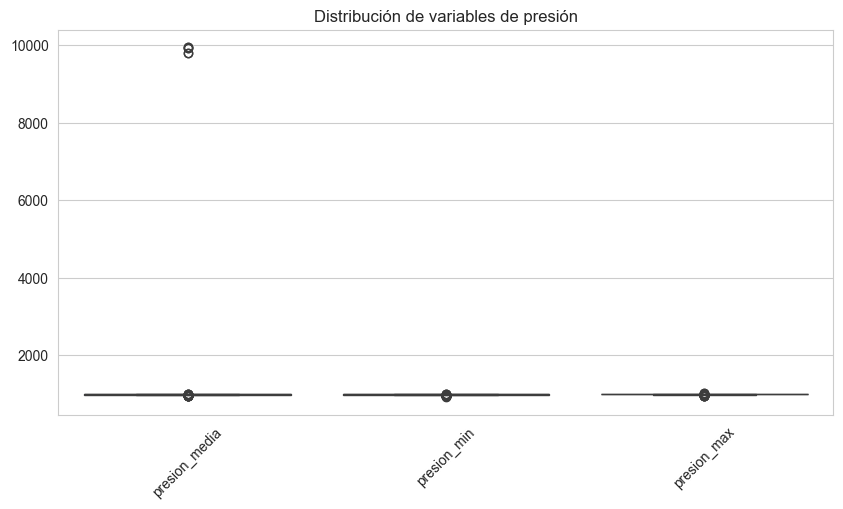

In [20]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data[["presion_media", "presion_min", "presion_max"]])
plt.title("Distribución de variables de presión")
plt.xticks(rotation=45)
plt.show()

### Valores atípicos

Los diagramas de caja permiten identificar observaciones extremas en las variables numéricas.

## 3.7 Relación entre variables


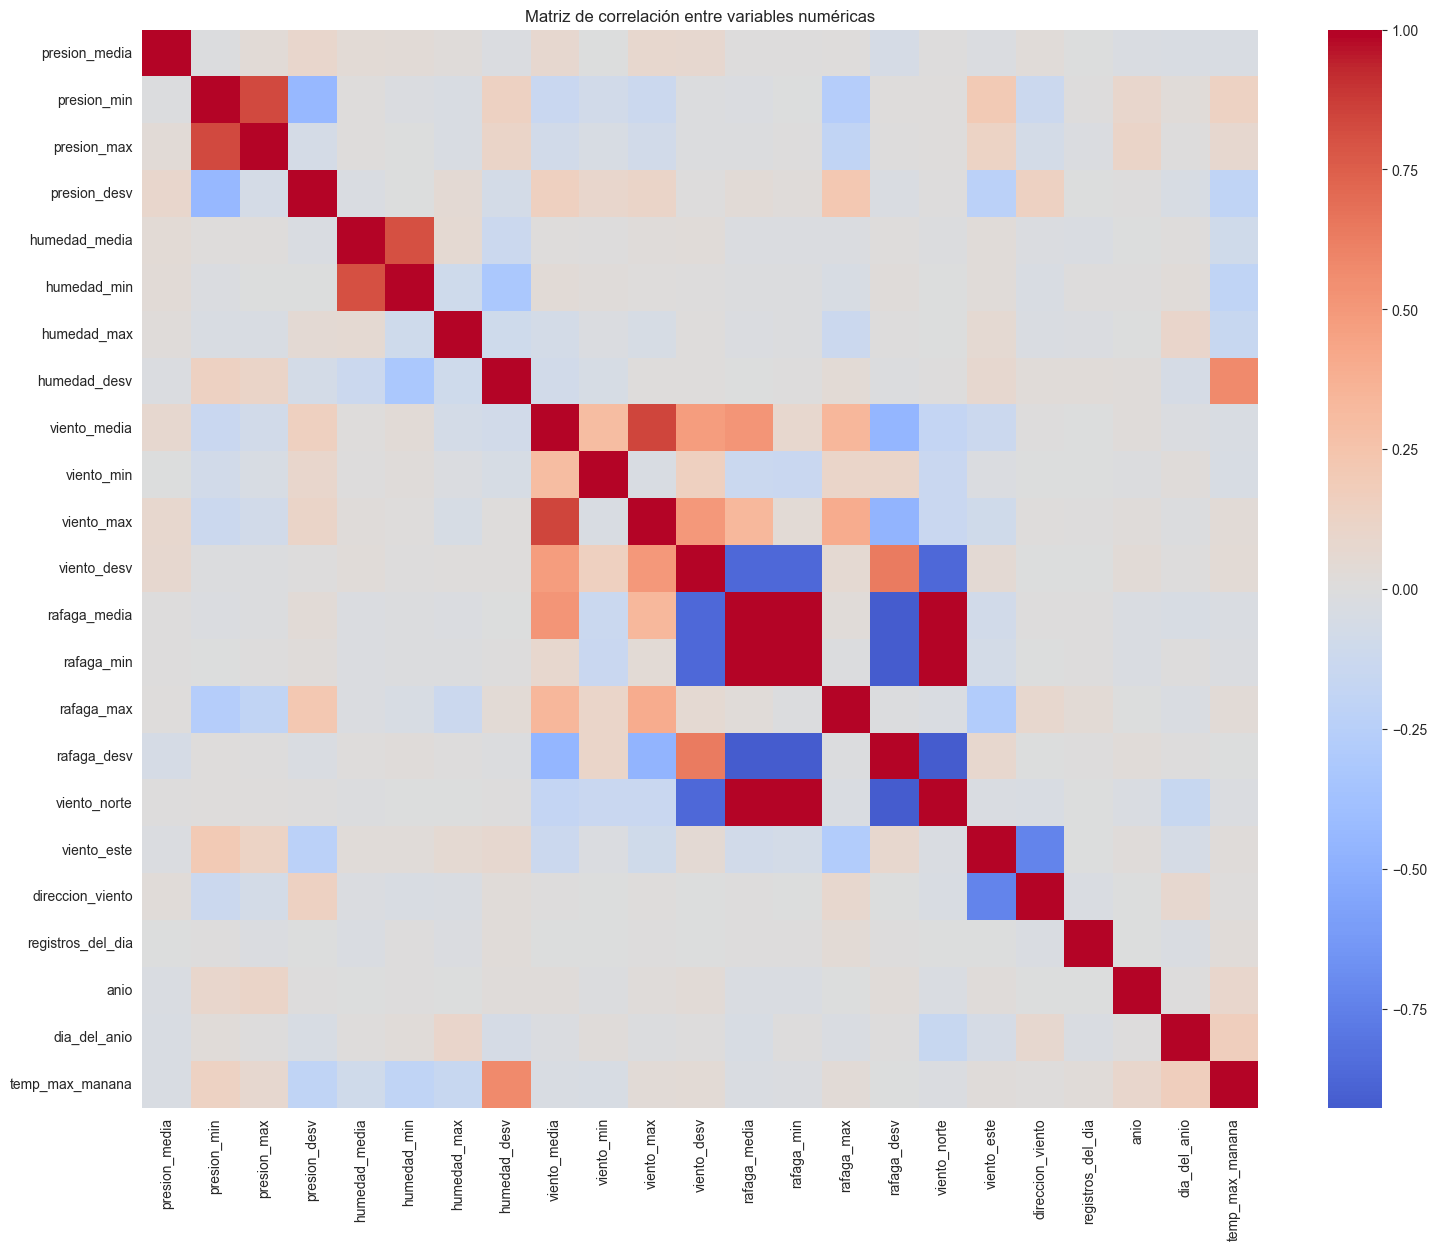

In [21]:
correlacion = data.select_dtypes(include=np.number).corr()

plt.figure(figsize=(18, 14))
sns.heatmap(
    correlacion,
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación entre variables numéricas")
plt.show()


In [22]:
correlacion_target = (
    correlacion["temp_max_manana"]
    .drop("temp_max_manana")
    .sort_values(ascending=False)
)

correlacion_target

humedad_desv         0.571459
dia_del_anio         0.165812
presion_min          0.141860
anio                 0.092718
presion_max          0.070861
viento_desv          0.040129
viento_max           0.031348
rafaga_max           0.030527
registros_del_dia    0.025923
viento_este          0.015941
direccion_viento     0.007824
rafaga_desv         -0.007027
rafaga_min          -0.019087
viento_norte        -0.020881
rafaga_media        -0.024158
presion_media       -0.032249
viento_media        -0.035994
viento_min          -0.039749
humedad_media       -0.098139
humedad_max         -0.155211
presion_desv        -0.199890
humedad_min         -0.203226
Name: temp_max_manana, dtype: float64

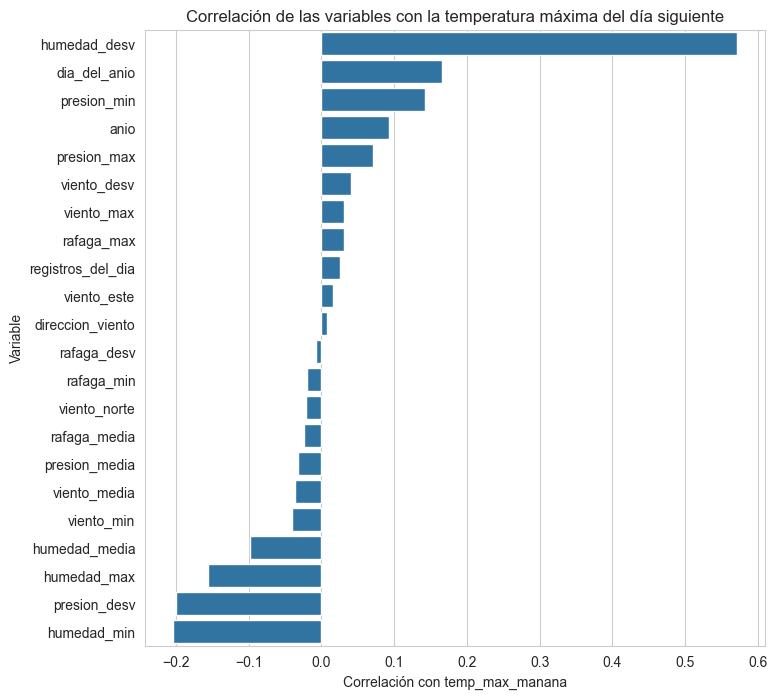

In [23]:
plt.figure(figsize=(8, 8))

sns.barplot(
    x=correlacion_target.values,
    y=correlacion_target.index
)

plt.xlabel("Correlación con temp_max_manana")
plt.ylabel("Variable")
plt.title("Correlación de las variables con la temperatura máxima del día siguiente")
plt.show()

### Análisis de correlaciones

La matriz de correlación permite observar asociaciones lineales entre las variables numéricas.

Además, se analizaron específicamente las correlaciones con `temp_max_manana`, ya que estas relaciones pueden aportar información inicial sobre qué variables podrían resultar útiles para la regresión.

## 3.8 Conclusiones del EDA

A partir de la exploración se identificaron varios problemas de calidad que deben corregirse antes del modelado:

- **Completitud:** existen valores faltantes en varias variables, aunque en proporciones bajas. La variable objetivo `temp_max_manana` también contiene registros faltantes.
- **Unicidad:** se encontraron registros completamente duplicados que deben tratarse antes de dividir los datos.
- **Consistencia:** las variables categóricas presentan diferentes formas de representar una misma categoría, especialmente en `mes`, `estacion_anio` y `sector_viento`.
- **Validez:** se encontraron valores claramente fuera de los rangos esperados, como valores extremos en presión, velocidades y ráfagas negativas, además de inconsistencias de escala en las variables de humedad.
- **Valores atípicos:** algunas variables presentan observaciones extremas. No todos estos valores se consideran errores automáticamente, por lo que su tratamiento debe depender del contexto y del diccionario de datos.
- **Relación entre variables:** existen asociaciones entre varias variables meteorológicas y `temp_max_manana`. También se observan variables altamente relacionadas entre sí, por lo que será importante considerar posibles redundancias durante el modelado.

Estos resultados justifican realizar una etapa de preparación antes de construir los modelos de regresión lineal.

# 4. Preparación de datos

A partir de los resultados obtenidos durante la exploración se identificaron problemas de completitud, unicidad, consistencia y validez que deben ser tratados antes de construir los modelos.

Las principales decisiones de preparación son:

1. Eliminar registros duplicados exactos.
2. Eliminar registros que no tienen valor para la variable objetivo `temp_max_manana`, ya que no es posible utilizarlos para entrenar un modelo supervisado.
3. Corregir inconsistencias en las variables categóricas `estacion_anio`, `mes` y `sector_viento`.
4. Corregir problemas evidentes de escala en algunas variables de humedad.
5. Marcar como faltantes los valores numéricos que representan errores claros o valores físicamente inválidos.
6. Imputar posteriormente los valores faltantes de las variables predictoras mediante un `Pipeline`, evitando utilizar información del conjunto de prueba durante el entrenamiento.
7. Codificar las variables categóricas y escalar las variables numéricas dentro del pipeline.

Estas decisiones se realizan con base en los problemas identificados durante el EDA y siguiendo la separación entre detección y corrección trabajada en clase.


## 4.1 Crear copia


In [24]:
data_preparada = data.copy()

print("Registros iniciales:", data_preparada.shape[0])

Registros iniciales: 2576


## 4.2 Eliminar duplicados

In [25]:
# Eliminar registros completamente duplicados
data_preparada = data_preparada.drop_duplicates().copy()

print("Registros después de eliminar duplicados:", data_preparada.shape[0])


Registros después de eliminar duplicados: 2572


### Tratamiento de duplicados

Durante el análisis de unicidad se encontraron 8 registros involucrados en duplicados exactos. Se conserva una sola copia de cada observación mediante `drop_duplicates()`.

Esta corrección evita que una misma observación tenga un peso artificialmente mayor durante el entrenamiento y reduce el riesgo de que registros idénticos aparezcan simultáneamente en entrenamiento y prueba.

## 4.3 Tratamiento variable objetivo

In [26]:
TARGET = "temp_max_manana"

print(
    "Registros sin variable objetivo:",
    data_preparada[TARGET].isna().sum()
)

data_preparada = data_preparada.dropna(subset=[TARGET]).copy()

print(
    "Registros después de eliminar target faltante:",
    data_preparada.shape[0]
)

Registros sin variable objetivo: 95
Registros después de eliminar target faltante: 2477


### Valores faltantes en la variable objetivo

La variable `temp_max_manana` presenta aproximadamente 3.69% de valores faltantes.

Como se trata de la etiqueta que el modelo debe aprender a predecir, estos valores no se imputan. Imputar la variable objetivo implicaría crear artificialmente las respuestas con las que se entrena el modelo.

Por esta razón se eliminan únicamente los registros que no contienen un valor conocido para `temp_max_manana`.

## 4.4 Corrección variables categóricas

In [27]:
mapa_estaciones = {
    # invierno
    "invierno": "invierno",
    "Invierno": "invierno",
    "INVIERNO": "invierno",
    "winter": "invierno",
    "invernio": "invierno",
    
    # primavera
    "primavera": "primavera",
    "Primavera": "primavera",
    "PRIMAVERA": "primavera",
    "spring": "primavera",
    "primaveraa": "primavera",
    "primav": "primavera",
    
    # verano
    "verano": "verano",
    "Verano": "verano",
    "VERANO": "verano",
    "summer": "verano",
    "berano": "verano",
    "verno": "verano",
    
    # otoño
    "otono": "otono",
    "otoño": "otono",
    "Otoño": "otono",
    "OTONO": "otono",
    "autumn": "otono",
    "fall": "otono"
}

data_preparada["estacion_anio"] = (
    data_preparada["estacion_anio"]
    .map(mapa_estaciones)
)

In [28]:
data_preparada["estacion_anio"].value_counts(dropna=False)

estacion_anio
primavera    551
verano       532
invierno     531
otono        531
NaN          332
Name: count, dtype: int64

In [29]:
# Convertir fecha a datetime
data_preparada["fecha"] = pd.to_datetime(
    data_preparada["fecha"],
    errors="coerce"
)

# Reconstruir el mes a partir de la fecha
data_preparada["mes"] = data_preparada["fecha"].dt.month

In [30]:
data_preparada["mes"].value_counts(dropna=False).sort_index()

mes
1.0     199
2.0     185
3.0     211
4.0     199
5.0     209
6.0     195
7.0     201
8.0     206
9.0     198
10.0    201
11.0    197
12.0    206
NaN      70
Name: count, dtype: int64

### Corrección de `mes`

Durante el EDA se encontraron 61 representaciones diferentes en la variable `mes`, aunque conceptualmente solo existen 12 meses.

Debido a que el conjunto también contiene la variable `fecha`, se reconstruye el mes directamente a partir de esta. Esta estrategia evita realizar correcciones manuales sobre múltiples variantes de nombres y utiliza una variable que contiene la misma información de forma más precisa.

## 4.5 Corregir humedad

In [31]:
columnas_humedad_porcentaje = [
    "humedad_media",
    "humedad_min",
    "humedad_max"
]

for columna in columnas_humedad_porcentaje:
    mascara_proporcion = (
        (data_preparada[columna] >= 0) &
        (data_preparada[columna] <= 1)
    )
    
    data_preparada.loc[
        mascara_proporcion,
        columna
    ] = data_preparada.loc[
        mascara_proporcion,
        columna
    ] * 100

In [32]:
data_preparada[
    columnas_humedad_porcentaje
].describe().T

,count,mean,std,min,25%,50%,75%,max
humedad_media,2405.0,75.157818,14.012643,0.466265,67.4299,76.7401,84.4688,100.000000
humedad_min,2397.0,59.825863,18.161416,1.003387,45.5000,58.8900,72.2000,103.311405
humedad_max,2393.0,90.282762,10.617034,27.020000,88.1000,93.3000,96.6000,100.000000


In [33]:
for columna in columnas_humedad_porcentaje:
    data_preparada.loc[
        (data_preparada[columna] < 0) |
        (data_preparada[columna] > 100),
        columna
    ] = np.nan

### Corrección de las variables de humedad

El diccionario define las variables de humedad relativa en porcentaje. Sin embargo, durante el EDA se observaron registros con valores entre 0 y 1 mientras otras observaciones se encuentran entre 0 y 100.

Debido a esta inconsistencia de escala, los valores de `humedad_media`, `humedad_min` y `humedad_max` comprendidos entre 0 y 1 se interpretan como proporciones y se multiplican por 100.

luego los valores fuera del intervalo válido de 0% a 100% se consideran inválidos y se reemplazan por valores faltantes para ser tratados posteriormente mediante imputación.

## 4.6 Errores numéricos evidentes

In [34]:
# Presiones físicamente inconsistentes con la escala
data_preparada.loc[
    data_preparada["presion_media"] > 2000,
    "presion_media"
] = np.nan

In [35]:
columnas_no_negativas = [
    "viento_media",
    "viento_min",
    "viento_max",
    "viento_desv",
    "rafaga_media",
    "rafaga_min",
    "rafaga_max",
    "rafaga_desv",
    "presion_desv",
    "humedad_desv"
]

for columna in columnas_no_negativas:
    data_preparada.loc[
        data_preparada[columna] < 0,
        columna
    ] = np.nan

In [36]:
data_preparada.loc[
    (data_preparada["direccion_viento"] < 0) |
    (data_preparada["direccion_viento"] > 360),
    "direccion_viento"
] = np.nan

In [37]:
data_preparada.loc[
    (data_preparada["dia_del_anio"] < 1) |
    (data_preparada["dia_del_anio"] > 366),
    "dia_del_anio"
] = np.nan

In [38]:
# Desviaciones físicamente imposibles.
# La desviación diaria de la velocidad del viento tiene mediana ≈ 1.05,
# pero un 10% de los registros toma valores entre 25 y 3319.
columnas_desviacion_invalida = [
    "viento_desv",
    "rafaga_desv"
]

for columna in columnas_desviacion_invalida:
    print(
        f"{columna}: {(data_preparada[columna] > 20).sum()} "
        f"registros con valores > 20"
    )

    data_preparada.loc[
        data_preparada[columna] > 20,
        columna
    ] = np.nan

# Componentes del vector de viento con magnitudes imposibles
for columna in ["viento_norte", "viento_este"]:
    print(
        f"{columna}: {(data_preparada[columna].abs() > 50).sum()} "
        f"registros con magnitud > 50"
    )

    data_preparada.loc[
        data_preparada[columna].abs() > 50,
        columna
    ] = np.nan

viento_desv: 249 registros con valores > 20
rafaga_desv: 1 registros con valores > 20
viento_norte: 1 registros con magnitud > 50
viento_este: 0 registros con magnitud > 50


### Corrección de valores extremos no físicos

Además de los errores de signo y de escala tratados antes, el EDA mostró
observaciones cuya **magnitud** es incompatible con la variable que representan:

| Variable | Mediana | Percentil 95 | Valor extremo | Registros afectados |
|---|---|---|---|---|
| `viento_desv` | 1.05 | 101.89 | 3319.03 | 249 |
| `rafaga_desv` | 1.55 | 2.96 | 3471.03 | 1 |
| `viento_norte` | −0.56 | 2.02 | −1250.46 | 1 |

En `viento_desv` el mayor valor por debajo del umbral es 3.92 y el siguiente valor
observado es 24.88, es decir, existe un **salto claro** entre ambos grupos que
permite separarlos sin ambigüedad. Una desviación diaria de 100 m/s en la velocidad del
viento no es posible cuando la velocidad media del mismo día es cercana a 9 m/s.

`presion_desv` (máximo 12.40) y `humedad_desv` (máximo 26.34) sí se encuentran
dentro de rangos plausibles para sus unidades, por lo que **no** se modifican.

Estos valores se reemplazan por `NaN` y se imputan después dentro del pipeline,
en lugar de eliminar el registro completo, ya que el resto de sus variables sigue
siendo información válida. Esta corrección resulta especialmente importante para la
etapa de interpretación: como se verifica en la sección 9, el registro del
`2015-07-13` introducía por sí solo una correlación de 0.999 entre `rafaga_desv` y
`viento_norte`, lo que hacía que sus coeficientes fueran completamente inestables.

In [39]:
data_preparada = data_preparada.drop(columns=["fecha"])

## 4.7 Revisar limpieza

In [40]:
print("Dimensiones después de la preparación inicial:")
print(data_preparada.shape)

print("\nValores faltantes:")
print(
    data_preparada.isnull()
    .sum()
    .sort_values(ascending=False)
)

Dimensiones después de la preparación inicial:
(2477, 26)

Valores faltantes:
estacion_anio        332
rafaga_desv          324
viento_desv          318
humedad_min          100
viento_min            90
humedad_max           84
viento_media          84
anio                  82
presion_desv          80
viento_norte          79
viento_max            77
rafaga_media          76
presion_media         76
direccion_viento      75
registros_del_dia     74
rafaga_max            73
humedad_media         72
mes                   70
rafaga_min            70
presion_min           69
sector_viento         67
dia_del_anio          64
presion_max           61
viento_este           60
humedad_desv          60
temp_max_manana        0
dtype: int64


In [41]:
data_preparada.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
presion_media,2401.0,NaN,NaN,NaN,989.121574,8.026424,948.996,984.2751,989.4299,994.3777,1011.6538
presion_min,2408.0,NaN,NaN,NaN,986.658781,8.928284,913.6,981.4075,987.07,992.5525,1012.320198
presion_max,2416.0,NaN,NaN,NaN,991.668526,7.71127,951.94,987.0375,991.935,996.7325,1013.94
presion_desv,2397.0,NaN,NaN,NaN,1.750611,1.205149,0.2269,0.8989,1.4446,2.2554,12.3975
humedad_media,2405.0,NaN,NaN,NaN,75.157818,14.012643,0.466265,67.4299,76.7401,84.4688,100.0
humedad_min,2377.0,NaN,NaN,NaN,59.476365,17.831506,1.003387,45.3,58.61,72.0,100.0
humedad_max,2393.0,NaN,NaN,NaN,90.282762,10.617034,27.02,88.1,93.3,96.6,100.0
humedad_desv,2417.0,NaN,NaN,NaN,10.63296,5.488592,0.0,6.1217,10.2149,14.7392,26.3416
viento_media,2393.0,NaN,NaN,NaN,3.808139,3.281033,0.0,1.6553,2.4624,4.893,24.42888
viento_min,2387.0,NaN,NaN,NaN,1.413859,3.965287,0.0,0.22,0.44,0.96,45.184956


## 4.8 Definición de X Y

In [42]:
TARGET = "temp_max_manana"

X = data_preparada.drop(columns=[TARGET])
y = data_preparada[TARGET]

print("Variables predictoras:", X.shape)
print("Variable objetivo:", y.shape)

Variables predictoras: (2477, 25)
Variable objetivo: (2477,)


## 4.9 Separación train/test

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1857, 25)
X_test: (620, 25)
y_train: (1857,)
y_test: (620,)


## 4.10 Preparación dentro del pipeline

In [44]:
columnas_categoricas = [
    "estacion_anio",
    "sector_viento"
]

columnas_numericas = [
    col for col in X.columns
    if col not in columnas_categoricas
]

In [45]:
transformador_numerico = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

transformador_categorico = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocesador = ColumnTransformer(
    transformers=[
        ("num", transformador_numerico, columnas_numericas),
        ("cat", transformador_categorico, columnas_categoricas)
    ]
)

# 5. Modelo 1 — Regresión lineal base

Como primera estrategia se construye un modelo base de regresión lineal utilizando las variables disponibles después de la limpieza hecha anteriormente.

El preprocesamiento definido en la etapa anterior aplica:

- imputación por mediana a las variables numéricas
- estandarización mediante `StandardScaler`
- imputación por moda a las variables categóricas
- codificación mediante `OneHotEncoder`

Todas estas transformaciones se encuentran dentro de un `Pipeline`, de manera que los parámetros de imputación y escalamiento se aprenden únicamente a partir del conjunto de entrenamiento. Esto evita utilizar información del conjunto de prueba durante el entrenamiento.

Este primer modelo funcionará como línea base para comparar posteriormente una segunda estrategia de preparación e ingeniería de características.


## 5.1 Construcción del pipeline


In [46]:
modelo_1 = Pipeline(
    steps=[
        ("preprocesamiento", preprocesador),
        ("regresion", LinearRegression())
    ]
)

modelo_1

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('regresion', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0

## 5.2 Entrenamiento

La regresión lineal busca representar la variable objetivo como una combinación lineal de las variables predictoras:

$$
\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p
$$

Los coeficientes son estimados buscando minimizar la suma de los errores cuadrados entre los valores reales y las predicciones del modelo.

El pipeline se ajusta únicamente utilizando el conjunto de entrenamiento.

In [47]:
modelo_1.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('regresion', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](25,)","['presion_media','presion_min','presion_max',...,'estacion_anio','mes', 'sector_viento']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,25
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed throug

## 5.3 Predicciones

In [48]:
# Predicciones sobre entrenamiento
y_train_pred_1 = modelo_1.predict(X_train)

# Predicciones sobre prueba
y_test_pred_1 = modelo_1.predict(X_test)

## 5.4 Evaluación cuantititativa

In [49]:
def calcular_metricas(y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2 = r2_score(y_real, y_pred)
    
    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [50]:
metricas_train_1 = calcular_metricas(
    y_train,
    y_train_pred_1
)

metricas_test_1 = calcular_metricas(
    y_test,
    y_test_pred_1
)

print("Métricas sobre entrenamiento:")
print(metricas_train_1)

print("\nMétricas sobre prueba:")
print(metricas_test_1)

Métricas sobre entrenamiento:
{'MAE': 5.167024004129076, 'RMSE': np.float64(6.793443077348866), 'R2': 0.45644597239242146}

Métricas sobre prueba:
{'MAE': 5.350462489062564, 'RMSE': np.float64(6.9015982224785635), 'R2': 0.44380854174819795}


In [51]:
resultados_modelo_1 = pd.DataFrame({
    "Conjunto": ["Train", "Test"],
    "MAE": [
        metricas_train_1["MAE"],
        metricas_test_1["MAE"]
    ],
    "RMSE": [
        metricas_train_1["RMSE"],
        metricas_test_1["RMSE"]
    ],
    "R2": [
        metricas_train_1["R2"],
        metricas_test_1["R2"]
    ]
})

resultados_modelo_1.set_index("Conjunto").round(4)

,MAE,RMSE,R2
Conjunto,,,
Train,5.1670,6.7934,0.4564
Test,5.3505,6.9016,0.4438


## 5.5 Interpretación inicial

El Modelo 1 obtuvo un **MAE de 5.1670** en entrenamiento y **5.3505** en prueba. Esto significa que, en promedio, las predicciones del modelo se alejan aproximadamente 5.35 °C del valor real de la temperatura máxima del día siguiente sobre datos no vistos.

El **RMSE fue de 6.7934 en entrenamiento y 6.9016 en prueba**. Al ser mayor que el MAE, indica que existen algunos errores de predicción relativamente grandes que reciben una penalización mayor al calcular esta métrica.

Por su parte, el **R² fue de 0.4564 en entrenamiento y 0.4438 en prueba**, por lo que el modelo explica aproximadamente el 44.4% de la variabilidad de `temp_max_manana` sobre el conjunto de prueba.

Las métricas obtenidas en entrenamiento y prueba son similares, por lo que no se observa una señal fuerte de sobreajuste. Sin embargo, el R² muestra que todavía existe una parte importante de la variabilidad de la temperatura que el modelo base no logra explicar. Por esta razón, este modelo se utilizará como punto de referencia para comparar una segunda estrategia de preparación e ingeniería de características.

# 6. Modelo 2 — Regresión lineal con ingeniería de características

El Modelo 1 se utilizará como línea base. Aunque sus resultados en entrenamiento y prueba son similares, el R² obtenido sobre prueba fue de 0.4438, por lo que todavía existe una parte importante de la variabilidad de la temperatura máxima que no está siendo explicada.

Para el segundo modelo se mantiene el algoritmo de **regresión lineal**, pero se modifica la estrategia de preparación mediante ingeniería y selección de características.

Las principales modificaciones son:

1. **Representación cíclica del día del año:** `dia_del_anio` se transforma mediante seno y coseno. Esto permite representar correctamente la naturaleza periódica del año, donde el final de diciembre y el inicio de enero son fechas cercanas.

2. **Representación cíclica de la dirección del viento:** la dirección en grados se transforma también mediante seno y coseno, ya que valores cercanos a 0° y 360° representan prácticamente la misma dirección.

3. **Creación de rangos diarios:** se crean variables que representan la diferencia entre los valores máximos y mínimos de presión, humedad, viento y ráfagas. Estas nuevas características resumen la variabilidad meteorológica durante el día.

4. **Reducción de redundancia:** después de crear los rangos se eliminan las variables mínimas y máximas utilizadas para construirlos. También se eliminan `mes`, `dia_del_anio`, `direccion_viento` y `sector_viento`, ya que su información se representa de una forma diferente en este modelo.

El objetivo es proporcionar al modelo una representación más adecuada de la información meteorológica sin cambiar el algoritmo utilizado, permitiendo comparar el efecto de una estrategia diferente de preparación de datos.

## 6.2 Función ing de características

In [52]:
from sklearn.preprocessing import FunctionTransformer

In [53]:
def ingenieria_modelo_2(df):
    df = df.copy()

    # -----------------------------------------
    # 1. Variables temporales cíclicas
    # -----------------------------------------
    df["dia_sin"] = np.sin(
        2 * np.pi * df["dia_del_anio"] / 365.25
    )

    df["dia_cos"] = np.cos(
        2 * np.pi * df["dia_del_anio"] / 365.25
    )

    # -----------------------------------------
    # 2. Dirección del viento cíclica
    # -----------------------------------------
    direccion_rad = np.deg2rad(df["direccion_viento"])

    df["direccion_sin"] = np.sin(direccion_rad)
    df["direccion_cos"] = np.cos(direccion_rad)

    # -----------------------------------------
    # 3. Rangos diarios
    # -----------------------------------------
    df["rango_presion"] = (
        df["presion_max"] - df["presion_min"]
    ).where(
        df["presion_max"] >= df["presion_min"],
        np.nan
    )

    df["rango_humedad"] = (
        df["humedad_max"] - df["humedad_min"]
    ).where(
        df["humedad_max"] >= df["humedad_min"],
        np.nan
    )

    df["rango_viento"] = (
        df["viento_max"] - df["viento_min"]
    ).where(
        df["viento_max"] >= df["viento_min"],
        np.nan
    )

    df["rango_rafaga"] = (
        df["rafaga_max"] - df["rafaga_min"]
    ).where(
        df["rafaga_max"] >= df["rafaga_min"],
        np.nan
    )

    # -----------------------------------------
    # 4. Eliminar variables reemplazadas
    # -----------------------------------------
    columnas_eliminar = [
        "dia_del_anio",
        "mes",
        "direccion_viento",
        "sector_viento",

        "presion_min",
        "presion_max",

        "humedad_min",
        "humedad_max",

        "viento_min",
        "viento_max",

        "rafaga_min",
        "rafaga_max"
    ]

    df = df.drop(
        columns=columnas_eliminar,
        errors="ignore"
    )

    return df

## 6.3 Revisar como quedan las variables

In [54]:
# Comprobación
X_train_m2 = ingenieria_modelo_2(X_train)

print("Dimensiones Modelo 1:", X_train.shape)
print("Dimensiones después de ingeniería:", X_train_m2.shape)

print("\nVariables del Modelo 2:")
print(X_train_m2.columns.tolist())

Dimensiones Modelo 1: (1857, 25)
Dimensiones después de ingeniería: (1857, 21)

Variables del Modelo 2:
['presion_media', 'presion_desv', 'humedad_media', 'humedad_desv', 'viento_media', 'viento_desv', 'rafaga_media', 'rafaga_desv', 'viento_norte', 'viento_este', 'registros_del_dia', 'anio', 'estacion_anio', 'dia_sin', 'dia_cos', 'direccion_sin', 'direccion_cos', 'rango_presion', 'rango_humedad', 'rango_viento', 'rango_rafaga']


In [55]:
columnas_numericas_m2 = (
    X_train_m2
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

columnas_categoricas_m2 = (
    X_train_m2
    .select_dtypes(include=["object", "category"])
    .columns
    .tolist()
)

print("Variables numéricas:")
print(columnas_numericas_m2)

print("\nVariables categóricas:")
print(columnas_categoricas_m2)

Variables numéricas:
['presion_media', 'presion_desv', 'humedad_media', 'humedad_desv', 'viento_media', 'viento_desv', 'rafaga_media', 'rafaga_desv', 'viento_norte', 'viento_este', 'registros_del_dia', 'anio', 'dia_sin', 'dia_cos', 'direccion_sin', 'direccion_cos', 'rango_presion', 'rango_humedad', 'rango_viento', 'rango_rafaga']

Variables categóricas:
['estacion_anio']


## 6.4 Pipeline de preprocesamiento

Igual que en el Modelo 1, las operaciones que requieren aprender información de los datos se realizan dentro del pipeline y se ajustan únicamente utilizando el conjunto de entrenamiento.

Para las variables numéricas se utiliza imputación por mediana y estandarización. La mediana se mantiene como estrategia de imputación debido a la presencia de valores extremos identificados durante el EDA.

Las variables categóricas se imputan mediante su categoría más frecuente y posteriormente se transforman mediante One-Hot Encoding.

En este modelo se utiliza `drop="first"` para eliminar una categoría de referencia en cada variable categórica y reducir redundancia entre las variables binarias generadas.

In [56]:
transformador_numerico_m2 = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

transformador_categorico_m2 = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            )
        )
    ]
)

In [57]:
preprocesador_2 = ColumnTransformer(
    transformers=[
        (
            "num",
            transformador_numerico_m2,
            columnas_numericas_m2
        ),
        (
            "cat",
            transformador_categorico_m2,
            columnas_categoricas_m2
        )
    ]
)

In [58]:
transformador_ingenieria = FunctionTransformer(
    ingenieria_modelo_2,
    validate=False
)

modelo_2 = Pipeline(
    steps=[
        (
            "ingenieria",
            transformador_ingenieria
        ),
        (
            "preprocesamiento",
            preprocesador_2
        ),
        (
            "regresion",
            LinearRegression()
        )
    ]
)

modelo_2

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('ingenieria', ...), ('preprocesamiento', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function ing...t 0x11ab9ca40>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=N

## 6.5 Entrenamiento del Modelo 2

Para que la comparación con el Modelo 1 sea válida, se utilizan exactamente los mismos conjuntos `X_train`, `X_test`, `y_train` y `y_test`.

De esta forma, cualquier diferencia en el rendimiento se puede atribuir principalmente a la estrategia de preparación e ingeniería de características y no a una partición diferente de los datos.

In [59]:
modelo_2.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('ingenieria', ...), ('preprocesamiento', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](25,)","['presion_media','presion_min','presion_max',...,'estacion_anio','mes', 'sector_viento']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,25
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function ing...t 0x11ab9ca40>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False


In [60]:
y_train_pred_2 = modelo_2.predict(X_train)
y_test_pred_2 = modelo_2.predict(X_test)

## 6.6 EValuación del modelo 2

In [61]:
metricas_train_2 = calcular_metricas(
    y_train,
    y_train_pred_2
)

metricas_test_2 = calcular_metricas(
    y_test,
    y_test_pred_2
)

In [62]:
resultados_modelo_2 = pd.DataFrame({
    "Conjunto": ["Train", "Test"],

    "MAE": [
        metricas_train_2["MAE"],
        metricas_test_2["MAE"]
    ],

    "RMSE": [
        metricas_train_2["RMSE"],
        metricas_test_2["RMSE"]
    ],

    "R2": [
        metricas_train_2["R2"],
        metricas_test_2["R2"]
    ]
})

resultados_modelo_2 = (
    resultados_modelo_2
    .set_index("Conjunto")
)

resultados_modelo_2.round(4)

,MAE,RMSE,R2
Conjunto,,,
Train,3.4743,4.8208,0.7263
Test,3.6285,4.9973,0.7084


## 6.7 Interpretación inicial del Modelo 2

El Modelo 2 obtuvo un **MAE de 3.4743 en entrenamiento y 3.6285 en prueba**. Esto significa que, sobre datos no vistos, las predicciones se alejan en promedio aproximadamente 3.63 °C del valor real de la temperatura máxima del día siguiente.

El **RMSE fue de 4.8208 en entrenamiento y 4.9973 en prueba**. Como el RMSE es mayor que el MAE, se evidencia la presencia de algunos errores relativamente grandes que reciben una penalización mayor en esta métrica.

El **R² fue de 0.7263 en entrenamiento y 0.7084 en prueba**, por lo que el modelo logra explicar aproximadamente el **70.8% de la variabilidad de `temp_max_manana`** sobre datos no vistos.

Las métricas obtenidas en entrenamiento y prueba son cercanas, lo que indica que no se observa una señal fuerte de sobreajuste y que el modelo mantiene un comportamiento similar al enfrentarse a datos nuevos.

Al compararlo con el Modelo 1, el Modelo 2 presenta una mejora importante en todas las métricas. En particular, el RMSE sobre test disminuyó de **6.9016 a 4.9973** y el R² aumentó de **0.4438 a 0.7084**. Esto indica que la nueva estrategia de ingeniería de características permitió representar mejor la información meteorológica y mejorar la capacidad predictiva de la regresión lineal.

La mayor parte de esta mejora proviene de la representación cíclica del día del año: el Modelo 1 recibía `dia_del_anio` como una variable lineal que crece de 1 a 365, lo que obliga a la regresión a suponer que la temperatura aumenta o disminuye de forma constante a lo largo del año. Las variables `dia_sin` y `dia_cos` permiten en cambio representar el ciclo estacional real.

# 7. Comparación de modelos

Se comparan los dos modelos construidos utilizando las mismas particiones de datos
(`test_size=0.25`, `random_state=42`) y las mismas métricas: **RMSE**, **MAE** y **R²**.

El RMSE se toma como métrica principal de comparación, siguiendo lo indicado en el
enunciado del laboratorio. El MAE y el R² se utilizan como métricas de apoyo para
interpretar el error en las unidades del problema (°C) y la proporción de
variabilidad explicada.

In [63]:
comparacion = pd.DataFrame([
    {
        "Modelo": "Modelo 1 — Regresión lineal base",
        **calcular_metricas(y_test, y_test_pred_1)
    },
    {
        "Modelo": "Modelo 2 — Ingeniería de características",
        **calcular_metricas(y_test, y_test_pred_2)
    }
])

comparacion = (
    comparacion
    .sort_values("RMSE")
    .set_index("Modelo")
    .round(4)
)

print("Rendimiento sobre el conjunto de PRUEBA (test)")
comparacion

Rendimiento sobre el conjunto de PRUEBA (test)


,MAE,RMSE,R2
Modelo,,,
Modelo 2 — Ingeniería de características,3.6285,4.9973,0.7084
Modelo 1 — Regresión lineal base,5.3505,6.9016,0.4438


In [64]:
# Tabla ampliada: entrenamiento vs prueba
comparacion_completa = pd.DataFrame([
    {"Modelo": "Modelo 1", "Conjunto": "Train", **calcular_metricas(y_train, y_train_pred_1)},
    {"Modelo": "Modelo 1", "Conjunto": "Test",  **calcular_metricas(y_test,  y_test_pred_1)},
    {"Modelo": "Modelo 2", "Conjunto": "Train", **calcular_metricas(y_train, y_train_pred_2)},
    {"Modelo": "Modelo 2", "Conjunto": "Test",  **calcular_metricas(y_test,  y_test_pred_2)}
])

comparacion_completa = (
    comparacion_completa
    .set_index(["Modelo", "Conjunto"])
    .round(4)
)

comparacion_completa

MAE    RMSE      R2
Modelo   Conjunto                        
Modelo 1 Train     5.1670  6.7934  0.4564
         Test      5.3505  6.9016  0.4438
Modelo 2 Train     3.4743  4.8208  0.7263
         Test      3.6285  4.9973  0.7084

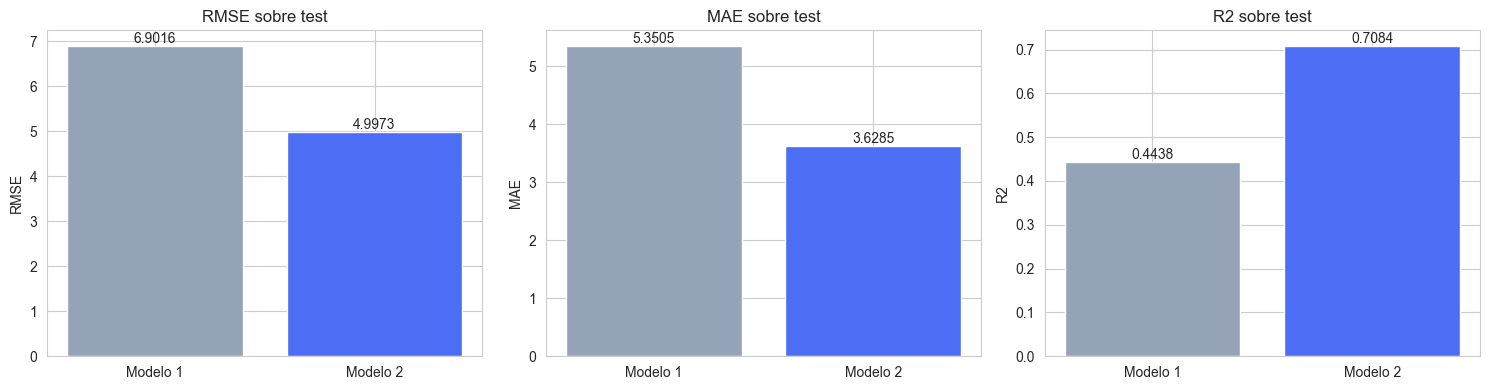

In [65]:
# Comparación visual de las métricas sobre test
metricas_plot = comparacion.reset_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metrica in zip(axes, ["RMSE", "MAE", "R2"]):
    ax.bar(
        ["Modelo 1", "Modelo 2"],
        metricas_plot.sort_values("Modelo")[metrica],
        color=["#94A3B8", "#4C6EF5"]
    )
    ax.set_title(f"{metrica} sobre test")
    ax.set_ylabel(metrica)

    for i, valor in enumerate(metricas_plot.sort_values("Modelo")[metrica]):
        ax.text(i, valor, f"{valor:.4f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

## 7.1 Selección del mejor modelo

**Modelo seleccionado:** Modelo 2 — Regresión lineal con ingeniería de características.

**Justificación:**

El Modelo 2 obtiene el mejor rendimiento sobre el conjunto de prueba en las tres
métricas evaluadas:

| Métrica | Modelo 1 | Modelo 2 | Diferencia |
|---|---|---|---|
| RMSE (test) | 6.9016 | **4.9973** | −1.90 °C (−27.6%) |
| MAE (test) | 5.3505 | **3.6285** | −1.72 °C (−32.2%) |
| R² (test) | 0.4438 | **0.7084** | +0.26 |

La diferencia **sí es relevante**, y no solo estadísticamente: el error típico de
predicción baja de casi 7 °C a 5 °C, y la proporción de variabilidad explicada pasa
del 44% al 71%. Para el caso de AlpesPlanck, donde el objetivo es anticipar
condiciones asociadas a incendios forestales, una reducción de casi dos grados en el
error típico cambia de forma importante la utilidad operativa del modelo.

Ambos modelos utilizan el **mismo algoritmo** (regresión lineal) y las **mismas
particiones**, por lo que toda la diferencia se atribuye a la estrategia de
preparación e ingeniería de características. Adicionalmente, en los dos casos la
distancia entre las métricas de entrenamiento y de prueba es pequeña
(RMSE train 4.8208 vs test 4.9973 en el Modelo 2), por lo que la mejora no proviene
de un sobreajuste al conjunto de entrenamiento.

Por lo tanto, el **Modelo 2** se utiliza como modelo final para la evaluación
cualitativa, la verificación de supuestos y la generación de las predicciones sobre
el conjunto sin etiquetar.

# 8. Evaluación cualitativa e interpretación

## 8.1 Coeficientes del mejor modelo

Una vez seleccionado el Modelo 2, se recuperan los nombres de las características
generadas por el pipeline (`get_feature_names_out()`) y se asocian con los
coeficientes estimados por la regresión.

Como todas las variables numéricas fueron estandarizadas con `StandardScaler` dentro
del pipeline, **los coeficientes son directamente comparables entre sí en magnitud**:
cada uno indica cuántos grados cambia la temperatura máxima estimada cuando la
variable aumenta en una desviación estándar, manteniendo las demás constantes.

In [66]:
mejor_modelo = modelo_2

preprocesamiento_final = mejor_modelo.named_steps["preprocesamiento"]
regresion_final = mejor_modelo.named_steps["regresion"]

nombres_caracteristicas = [
    nombre.replace("num__", "").replace("cat__", "")
    for nombre in preprocesamiento_final.get_feature_names_out()
]

print("Número de características:", len(nombres_caracteristicas))
print("Intercepto (β₀):", round(regresion_final.intercept_, 4))

Número de características: 23
Intercepto (β₀): 13.4828


In [67]:
coeficientes = (
    pd.DataFrame({
        "Variable": nombres_caracteristicas,
        "Coeficiente": regresion_final.coef_
    })
    .assign(Importancia=lambda df: df["Coeficiente"].abs())
    .sort_values("Importancia", ascending=False)
    .reset_index(drop=True)
)

coeficientes.round(4)

,Variable,Coeficiente,Importancia
0,dia_cos,-6.3454,6.3454
1,dia_sin,-2.1366,2.1366
2,viento_norte,-1.6009,1.6009
3,estacion_anio_primavera,1.2129,1.2129
4,direccion_sin,1.1798,1.1798
5,humedad_desv,1.1697,1.1697
6,anio,0.7407,0.7407
7,presion_media,0.6830,0.6830
8,presion_desv,-0.5992,0.5992
9,direccion_cos,-0.5820,0.5820


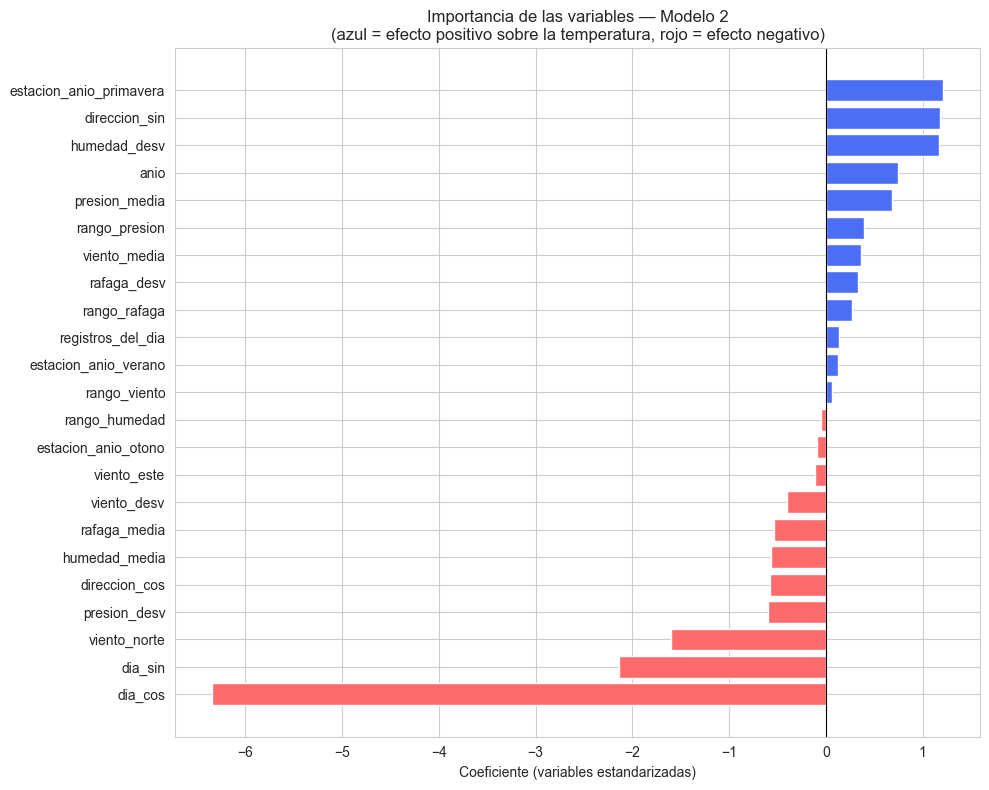

In [68]:
# Visualización de la importancia de las variables
coef_orden = coeficientes.sort_values("Coeficiente")
colores = [
    "#FF6B6B" if c < 0 else "#4C6EF5"
    for c in coef_orden["Coeficiente"]
]

plt.figure(figsize=(10, 8))
plt.barh(
    coef_orden["Variable"],
    coef_orden["Coeficiente"],
    color=colores
)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coeficiente (variables estandarizadas)")
plt.title(
    "Importancia de las variables — Modelo 2\n"
    "(azul = efecto positivo sobre la temperatura, rojo = efecto negativo)"
)
plt.tight_layout()
plt.show()

In [69]:
# Amplitud del componente estacional (dia_sin y dia_cos actúan en conjunto)
coef_cos = coeficientes.loc[
    coeficientes["Variable"] == "dia_cos", "Coeficiente"
].values[0]

coef_sin = coeficientes.loc[
    coeficientes["Variable"] == "dia_sin", "Coeficiente"
].values[0]

amplitud = np.sqrt(coef_cos ** 2 + coef_sin ** 2)

dia_maximo = (
    np.arctan2(coef_sin, coef_cos) / (2 * np.pi) * 365.25
) % 365.25

print("Amplitud del ciclo estacional:", round(amplitud, 4))
print("Día del año con temperatura máxima estimada:", round(dia_maximo, 1))

Amplitud del ciclo estacional: 6.6955
Día del año con temperatura máxima estimada: 201.5


### Interpretación de los coeficientes

**¿Cuáles variables tienen los coeficientes de mayor magnitud?**

El par estacional `dia_cos` (−6.3454) y `dia_sin` (−2.1366) domina claramente el
modelo. Estas dos variables no se interpretan por separado: actúan en conjunto como
una única onda anual cuya amplitud es
$\sqrt{\beta_{cos}^2 + \beta_{sin}^2} \approx 6.70$ y cuyo máximo se ubica
alrededor del **día 201 del año (≈ 20 de julio)**. Es decir, el modelo aprendió el
ciclo estacional de Jena, con el pico de temperatura a mediados de julio, lo cual
coincide con el verano del hemisferio norte.

Después del componente estacional, las variables más influyentes son
`viento_norte` (−1.6009), `estacion_anio_primavera` (+1.2129), `direccion_sin`
(+1.1798) y `humedad_desv` (+1.1697).

**¿Qué significa el signo?**

Un coeficiente positivo indica que, al aumentar esa variable en una desviación
estándar, la temperatura máxima estimada del día siguiente **sube**; uno negativo,
que **baja**. Los signos obtenidos son coherentes con la física del problema:

- `viento_norte` (−1.60): entre más componente de viento proveniente del norte,
  menor temperatura. En el hemisferio norte el aire del norte es aire polar.
- `presion_media` (+0.6830): la alta presión se asocia a condiciones anticiclónicas,
  cielo despejado y mayor calentamiento diurno.
- `humedad_media` (−0.5703): mayor humedad se asocia a nubosidad y menor
  temperatura máxima.
- `rafaga_media` (−0.5324) y `viento_desv` (−0.4036): días ventosos y de condiciones
  inestables tienden a ser más fríos.
- `anio` (+0.7407): a igualdad de las demás condiciones, los años más recientes
  presentan temperaturas máximas más altas. Esta variable captura la **tendencia de
  calentamiento** del periodo 2003–2016 registrado por la estación.

**¿Qué interpretación tiene en el contexto meteorológico?**

El modelo reproduce la estructura esperada del fenómeno: la temperatura máxima del
día siguiente se explica principalmente por **dónde está el año** (estacionalidad) y,
en segundo lugar, por el **estado sinóptico del día actual** (presión, humedad,
dirección e intensidad del viento). Para AlpesPlanck esto implica que un sistema de
alerta temprana debe combinar la referencia estacional con el seguimiento diario de
presión, humedad y dirección del viento.

**¿La escala permite comparar los coeficientes directamente?**

Sí. Todas las variables numéricas pasan por `StandardScaler` dentro del pipeline, de
modo que están expresadas en desviaciones estándar y sus coeficientes son
comparables entre sí. Sin ese escalamiento, variables como `presion_media`
(≈ 990 hPa) y `viento_norte` (≈ 0–5 m/s) tendrían coeficientes de órdenes de
magnitud distintos y la comparación no sería válida. Las variables categóricas
provienen de `OneHotEncoder(drop="first")`, por lo que sus coeficientes se
interpretan **frente a la categoría de referencia** (`invierno`).

# 9. Verificación de supuestos de la regresión lineal

Las métricas de la sección 7 indican qué tan bien **predice** el modelo. Los
supuestos de la regresión lineal indican si además podemos **explicar** con él, es
decir, si los coeficientes de la sección 8 pueden interpretarse de forma confiable y
si tienen sentido las pruebas de significancia estadística sobre ellos.

| Supuesto | ¿Qué verifica? | Prueba de diagnóstico |
|---|---|---|
| **No colinealidad** | Que las variables predictoras no estén correlacionadas entre sí | VIF |
| **Linealidad** | Que la relación entre X e y sea razonablemente lineal | Test de Rainbow |
| **Normalidad de errores** | Que los residuales se distribuyan normalmente | Shapiro-Wilk, Q-Q plot |
| **Homocedasticidad** | Que la varianza de los residuales sea constante | Breusch-Pagan |
| **Independencia de errores** | Que los errores no estén autocorrelacionados | Durbin-Watson |

> Si un supuesto no se cumple, el modelo **sigue prediciendo**: sus métricas de
> error no cambian. Lo que se pierde es la validez de la interpretación estadística
> de los coeficientes.

Todas las pruebas se realizan sobre el **conjunto de entrenamiento**, que es el que
se usó para estimar los coeficientes.

In [70]:
# Datos transformados por el pipeline (necesarios para las pruebas estadísticas)
X_train_ingenieria = mejor_modelo.named_steps["ingenieria"].transform(X_train)
Xt_train = preprocesamiento_final.transform(X_train_ingenieria)

if scipy.sparse.issparse(Xt_train):
    Xt_train = Xt_train.toarray()

Xt_train_df = pd.DataFrame(
    Xt_train,
    columns=nombres_caracteristicas,
    index=X_train.index
)

# Residuales del mejor modelo sobre entrenamiento
residuales = np.array(y_train - mejor_modelo.predict(X_train))

print("Matriz transformada:", Xt_train_df.shape)
print("Media de los residuales:", round(residuales.mean(), 6))

Matriz transformada: (1857, 23)
Media de los residuales: -0.0


## 9.1 No colinealidad (VIF)

La multicolinealidad ocurre cuando dos o más variables predictoras están altamente
correlacionadas entre sí. No impide predecir, pero vuelve **inestables** los
coeficientes individuales: el modelo no puede separar el efecto de una variable del
de la otra.

Se mide con el **Factor de Inflación de la Varianza (VIF)**:

- **VIF ≈ 1**: sin colinealidad.
- **VIF entre 5 y 10**: colinealidad moderada, revisar con cuidado.
- **VIF > 10**: colinealidad alta, coeficientes poco confiables.

In [71]:
vif_data = pd.DataFrame({
    "Variable": Xt_train_df.columns,
    "VIF": [
        variance_inflation_factor(Xt_train_df.values, i)
        for i in range(Xt_train_df.shape[1])
    ]
}).sort_values("VIF", ascending=False)

vif_data.round(3)

,Variable,VIF
7,rafaga_desv,10.749
5,viento_desv,10.569
1,presion_desv,6.263
16,rango_presion,6.223
3,humedad_desv,6.165
17,rango_humedad,5.762
8,viento_norte,5.626
9,viento_este,5.252
4,viento_media,3.992
15,direccion_cos,3.623


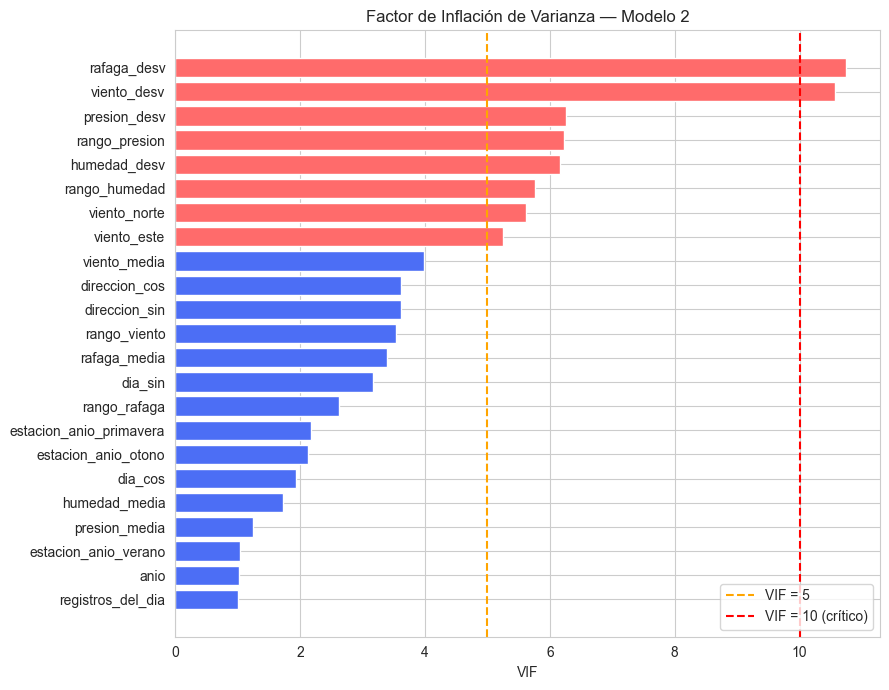

In [72]:
vif_orden = vif_data.sort_values("VIF")
colores_vif = [
    "#FF6B6B" if v >= 5 else "#4C6EF5"
    for v in vif_orden["VIF"]
]

plt.figure(figsize=(9, 7))
plt.barh(vif_orden["Variable"], vif_orden["VIF"], color=colores_vif)
plt.axvline(5, color="orange", linestyle="--", lw=1.5, label="VIF = 5")
plt.axvline(10, color="red", linestyle="--", lw=1.5, label="VIF = 10 (crítico)")
plt.xlabel("VIF")
plt.title("Factor de Inflación de Varianza — Modelo 2")
plt.legend()
plt.tight_layout()
plt.show()

### Análisis de la multicolinealidad

Los valores más altos son `rafaga_desv` (**10.75**) y `viento_desv` (**10.57**), justo
en el límite crítico, seguidos por `presion_desv` (6.26), `rango_presion` (6.22),
`humedad_desv` (6.17), `rango_humedad` (5.76), `viento_norte` (5.63) y `viento_este`
(5.25). El resto de las variables se mantiene por debajo de 5.

Estos valores tienen una explicación directa: las variables de desviación y los
rangos diarios que construimos en la sección 6 miden **la misma idea de dispersión
del día** desde dos ángulos distintos. Un día ventoso e inestable tiene a la vez
mayor `viento_desv`, mayor `rafaga_desv` y mayor `rango_viento`.

**Conclusión:** el supuesto se cumple de forma parcial. La colinealidad es moderada y
está concentrada en el bloque de variabilidad intradiaria del viento y la presión,
por lo que los coeficientes de ese bloque en particular deben interpretarse con
cautela y no de forma individual. Los coeficientes del componente estacional
(`dia_sin`, `dia_cos`, VIF ≈ 3.2 y 1.9) y de `presion_media` (VIF ≈ 1.24), que son
los que sustentan las conclusiones principales de la sección 8, sí son estables.

> Vale la pena resaltar el efecto de la limpieza realizada en la sección 4.6: antes de
> anular los valores no físicos, `rafaga_desv` y `viento_norte` presentaban una
> correlación de 0.999 y un **VIF cercano a 1970**, producto de un único registro
> corrupto. Sus coeficientes eran de −28.7 y +28.7, es decir, dos efectos enormes que
> se cancelaban entre sí y que habrían llevado a una interpretación completamente
> equivocada de cuáles variables importan.

## 9.2 Normalidad de los errores

Este supuesto establece que los residuales $e_i = y_i - \hat{y}_i$ deben seguir
aproximadamente una distribución normal. Si se cumple, las pruebas t y F sobre los
coeficientes y los intervalos de confianza de las predicciones son válidos.

- **Shapiro-Wilk**: p-value > 0.05 → no se rechaza la normalidad.
- **Histograma**: debería verse como una campana simétrica.
- **Q-Q plot**: los puntos deberían seguir la línea diagonal.

In [73]:
estadistico_shapiro, p_shapiro = shapiro(residuales)

print("Shapiro-Wilk estadístico:", round(estadistico_shapiro, 4))
print("Shapiro-Wilk p-value    :", p_shapiro)
print("Asimetría (skewness)    :", round(stats.skew(residuales), 4))
print("Curtosis                :", round(stats.kurtosis(residuales), 4))

Shapiro-Wilk estadístico: 0.8912
Shapiro-Wilk p-value    : 2.6197620188333344e-34
Asimetría (skewness)    : 1.8765
Curtosis                : 17.3537


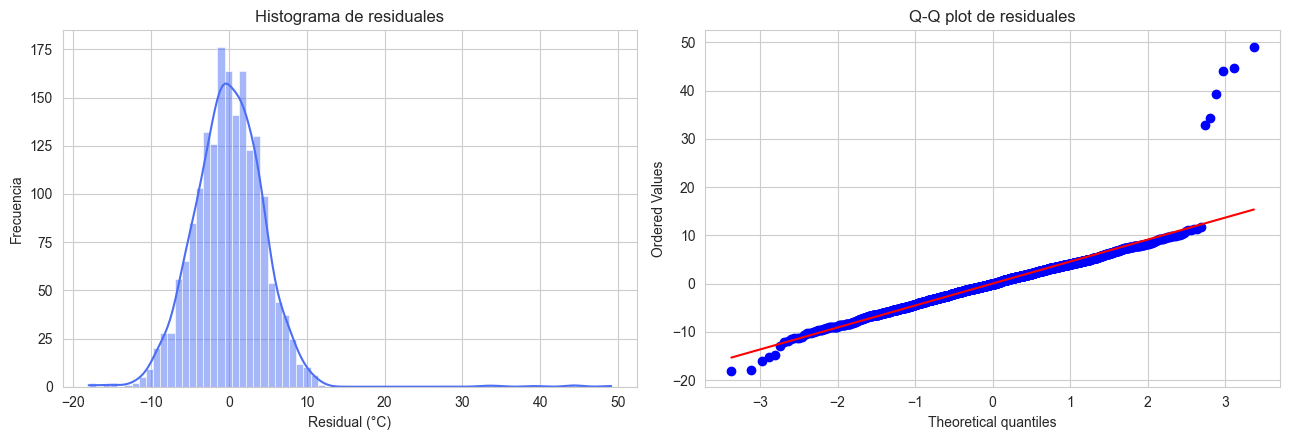

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(residuales, kde=True, ax=axes[0], color="#4C6EF5")
axes[0].set_title("Histograma de residuales")
axes[0].set_xlabel("Residual (°C)")
axes[0].set_ylabel("Frecuencia")

stats.probplot(residuales, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot de residuales")

plt.tight_layout()
plt.show()

### Análisis de la normalidad

La prueba de Shapiro-Wilk arroja un estadístico de **0.8912** y un p-value de
**2.62 × 10⁻³⁴**, prácticamente cero, por lo que se rechaza la hipótesis de
normalidad de los residuales.

Las gráficas confirman el resultado y explican de dónde viene. El histograma muestra
que la gran mayoría de los errores se concentra alrededor de 0, pero existe una
**cola larga hacia valores positivos**: la asimetría es de **1.88** y la curtosis de
**17.35**, muy por encima del valor 0 esperado para una normal. En el Q-Q plot los
puntos siguen la diagonal en la zona central y se separan de manera marcada en los
extremos, sobre todo en el superior.

Esto significa que el modelo comete la mayoría de sus errores dentro de un rango
razonable, pero que existe un grupo reducido de días en los que **subestima
fuertemente** la temperatura máxima. Son probablemente días de cambio brusco de masa
de aire, en los que la información del día anterior no anticipa lo que ocurre al día
siguiente.

**Conclusión:** el supuesto **no se cumple**. En consecuencia, no podemos apoyarnos
en pruebas t o F sobre los coeficientes ni construir intervalos de confianza exactos.
La comparación de magnitudes de la sección 8 sigue siendo informativa como medida de
importancia relativa, pero no como una afirmación de significancia estadística.

## 9.3 Homocedasticidad

La varianza de los errores debe ser constante para todos los niveles de las
variables explicativas: el modelo debería equivocarse con intensidad similar en días
fríos y en días calurosos.

Se verifica con la prueba de **Breusch-Pagan**: un p-value < 0.05 indica
heterocedasticidad.

In [75]:
Xt_train_const = sm.add_constant(Xt_train_df)

bp_estadistico, bp_pvalue, _, _ = het_breuschpagan(
    residuales,
    Xt_train_const.values
)

print("Breusch-Pagan estadístico:", round(bp_estadistico, 4))
print("Breusch-Pagan p-value    :", bp_pvalue)

Breusch-Pagan estadístico: 56.6261
Breusch-Pagan p-value    : 0.00011565408934128212


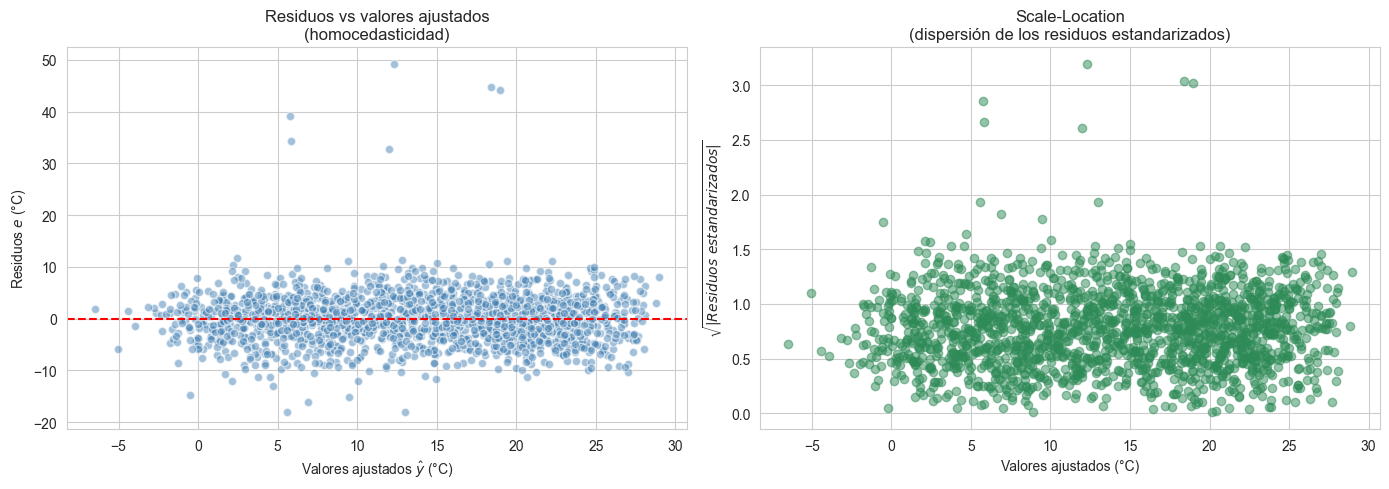

In [76]:
valores_ajustados = mejor_modelo.predict(X_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    valores_ajustados, residuales,
    alpha=0.5, color="steelblue", edgecolors="white"
)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Residuos vs valores ajustados\n(homocedasticidad)")
axes[0].set_xlabel(r"Valores ajustados $\hat{y}$ (°C)")
axes[0].set_ylabel("Residuos $e$ (°C)")

axes[1].scatter(
    valores_ajustados, np.sqrt(np.abs(residuales / residuales.std())),
    alpha=0.5, color="seagreen"
)
axes[1].set_title("Scale-Location\n(dispersión de los residuos estandarizados)")
axes[1].set_xlabel("Valores ajustados (°C)")
axes[1].set_ylabel(r"$\sqrt{|Residuos\ estandarizados|}$")

plt.tight_layout()
plt.show()

### Análisis de la homocedasticidad

La prueba de Breusch-Pagan entrega un estadístico de **56.63** y un p-value de
**1.16 × 10⁻⁴**, menor a 0.05, por lo que se rechaza la hipótesis de varianza
constante.

El gráfico de residuos contra valores ajustados muestra la razón: la nube no tiene un
ancho uniforme. La dispersión es visiblemente mayor en la zona de temperaturas
ajustadas intermedias y bajas (entre 0 y 15 °C) que en el extremo superior. Esto es
coherente con el clima de la región: los días de invierno y las transiciones
estacionales son meteorológicamente más variables que los días plenamente
establecidos de verano.

**Conclusión:** el supuesto **no se cumple**. Los errores estándar de los
coeficientes están mal estimados, lo que refuerza la conclusión de la sección 9.2:
el modelo se usa para predecir y para ordenar la importancia relativa de las
variables, no para hacer inferencia estadística formal sobre ellas. En términos
prácticos, también implica que **la confianza en la predicción no es la misma todo el
año**: es menor en invierno y en las transiciones que en verano.

## 9.4 Independencia de los errores

El error de una observación no debería influir en el de la siguiente. Se evalúa con
el estadístico de **Durbin-Watson**, que varía entre 0 y 4:

| Valor | Interpretación |
|---|---|
| Cercano a 0 | Autocorrelación positiva |
| Cercano a 2 | Sin autocorrelación |
| Cercano a 4 | Autocorrelación negativa |

In [77]:
dw = durbin_watson(residuales)
print("Durbin-Watson:", round(dw, 4))

Durbin-Watson: 2.0414


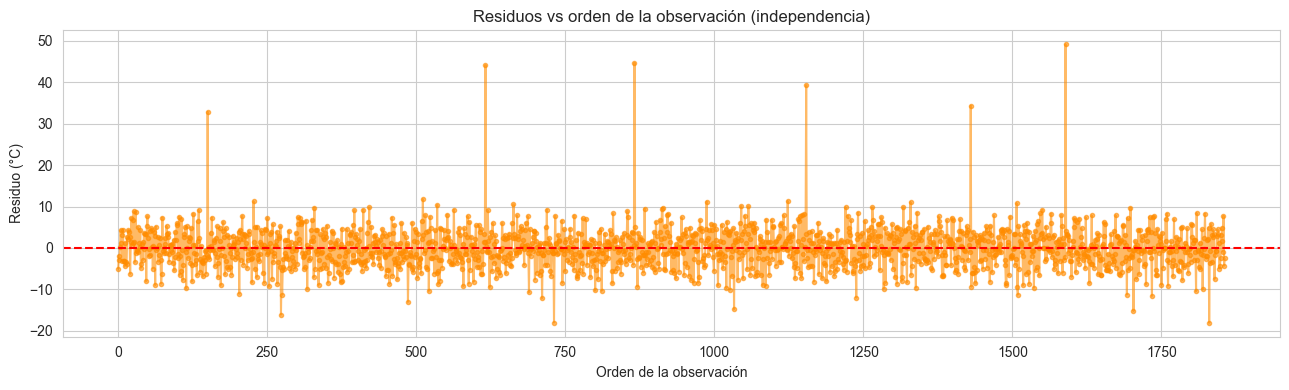

In [78]:
plt.figure(figsize=(13, 4))
plt.plot(
    range(len(residuales)), residuales,
    marker="o", linestyle="-", markersize=3,
    alpha=0.6, color="darkorange"
)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuos vs orden de la observación (independencia)")
plt.xlabel("Orden de la observación")
plt.ylabel("Residuo (°C)")
plt.tight_layout()
plt.show()

### Análisis de la independencia

El estadístico de Durbin-Watson es **2.0414**, muy cercano a 2, y la gráfica de
residuos contra el orden de la observación no muestra tendencias ni patrones
cíclicos.

**Conclusión:** el supuesto **se cumple**. No se detecta autocorrelación entre los
errores.

Es importante matizar este resultado: los datos son una **serie de tiempo**, pero
`train_test_split` con `random_state=42` mezcla los días de forma aleatoria, por lo
que el orden de las filas en `X_train` ya no es el orden cronológico. El estadístico
confirma que no hay autocorrelación en ese orden mezclado, no que no exista
dependencia temporal en la serie original. Esta limitación se retoma en la
sección 13.

## 9.5 Linealidad

La relación entre las variables explicativas y la media de `temp_max_manana` debe
poder describirse razonablemente mediante una combinación lineal. Se evalúa con el
**test de Rainbow**, que compara el ajuste del modelo en un subconjunto central
contra el ajuste sobre todos los datos. Un p-value > 0.05 indica que no hay evidencia
para rechazar la linealidad.

In [79]:
modelo_sm = sm.OLS(y_train, Xt_train_const).fit()

rainbow_estadistico, rainbow_pvalue = linear_rainbow(modelo_sm)

print("Rainbow estadístico:", round(rainbow_estadistico, 4))
print("Rainbow p-value    :", round(rainbow_pvalue, 4))

Rainbow estadístico: 0.9649
Rainbow p-value    : 0.7058


### Análisis de la linealidad

El test de Rainbow entrega un estadístico de **0.9649** y un p-value de **0.7058**,
muy por encima de 0.05, por lo que **no hay evidencia para rechazar la linealidad**.

**Conclusión:** el supuesto **se cumple**. Este resultado valida directamente la
decisión de ingeniería de características del Modelo 2: al transformar el día del año
y la dirección del viento en componentes cíclicas (seno y coseno), relaciones que en
su forma original eran claramente no lineales quedaron expresadas de una manera que
la regresión lineal sí puede representar. El Modelo 1, que usaba `dia_del_anio` como
una variable lineal creciente de 1 a 365, no tenía esa ventaja.

## 9.6 Resumen de la verificación de supuestos

In [80]:
resumen_supuestos = pd.DataFrame({
    "Supuesto": [
        "Linealidad",
        "Independencia de errores",
        "No colinealidad",
        "Normalidad de errores",
        "Homocedasticidad"
    ],
    "Prueba": [
        "Rainbow",
        "Durbin-Watson",
        "VIF",
        "Shapiro-Wilk",
        "Breusch-Pagan"
    ],
    "Resultado": [
        f"p = {rainbow_pvalue:.4f}",
        f"DW = {dw:.4f}",
        f"VIF máx = {vif_data['VIF'].max():.2f}",
        f"p = {p_shapiro:.2e}",
        f"p = {bp_pvalue:.2e}"
    ],
    "¿Se cumple?": [
        "Sí (p > 0.05)",
        "Sí (DW ≈ 2)",
        "Parcialmente (2 variables ≈ 10)",
        "No (p < 0.05)",
        "No (p < 0.05)"
    ],
    "Impacto": [
        "Sin impacto",
        "Sin impacto",
        "Coeficientes del bloque de viento poco separables",
        "Pruebas t/F no válidas",
        "Errores estándar mal estimados"
    ]
})

resumen_supuestos

,Supuesto,Prueba,Resultado,¿Se cumple?,Impacto
0,Linealidad,Rainbow,p = 0.7058,Sí (p > 0.05),Sin impacto
1,Independencia de errores,Durbin-Watson,DW = 2.0414,Sí (DW ≈ 2),Sin impacto
2,No colinealidad,VIF,VIF máx = 10.75,Parcialmente (2 variables ≈ 10),Coeficientes del bloque de viento poco separables
3,Normalidad de errores,Shapiro-Wilk,p = 2.62e-34,No (p < 0.05),Pruebas t/F no válidas
4,Homocedasticidad,Breusch-Pagan,p = 1.16e-04,No (p < 0.05),Errores estándar mal estimados


### ¿Qué implica este diagnóstico?

El modelo **sí puede usarse para predecir** la temperatura máxima: el RMSE de 4.9973 °C
sobre test no se ve afectado por el incumplimiento de los supuestos, y los dos
supuestos que sostienen la forma del modelo (linealidad e independencia) se cumplen.

Lo que **no** podemos hacer de forma confiable:

- Afirmar que una variable es "estadísticamente significativa" mediante una prueba t.
- Construir intervalos de confianza exactos alrededor de las predicciones.
- Interpretar de manera aislada los coeficientes del bloque de variabilidad del
  viento (`viento_desv`, `rafaga_desv`, `rango_viento`), que están correlacionados
  entre sí.

Lo que **sí** sostiene el diagnóstico: la lectura de la sección 8 sobre cuáles
variables aportan más a la predicción y con qué signo, en particular el componente
estacional, `presion_media`, `humedad_media` y `viento_norte`, que tienen VIF bajos.

**Posibles mejoras futuras**, fuera del alcance de este laboratorio: aplicar
regresión regularizada (Ridge o Lasso), que es más robusta a la colinealidad;
consolidar el bloque de variabilidad del viento en un solo indicador; o incorporar
temperaturas de días anteriores como predictores, que hoy no están disponibles en el
conjunto de datos y que probablemente explicarían buena parte de la cola de errores
grandes.

# 10. Análisis de resultados

En esta sección se responden de forma explícita las preguntas planteadas en el
enunciado del laboratorio.

## 10.1 ¿Cuál fue el valor de los diferentes coeficientes obtenidos en el mejor modelo?

**Respuesta:**

El mejor modelo es el **Modelo 2**, con un intercepto de **β₀ = 13.4828** y 23
coeficientes (20 variables numéricas y 3 indicadoras de estación, con `invierno`
como categoría de referencia). La tabla completa está en la sección 8.1; los
coeficientes ordenados por magnitud son:

| Variable | Coeficiente | | Variable | Coeficiente |
|---|---|---|---|---|
| `dia_cos` | −6.3454 | | `viento_desv` | −0.4036 |
| `dia_sin` | −2.1366 | | `rango_presion` | +0.3888 |
| `viento_norte` | −1.6009 | | `viento_media` | +0.3599 |
| `estacion_anio_primavera` | +1.2129 | | `rafaga_desv` | +0.3329 |
| `direccion_sin` | +1.1798 | | `rango_rafaga` | +0.2687 |
| `humedad_desv` | +1.1697 | | `registros_del_dia` | +0.1361 |
| `anio` | +0.7407 | | `estacion_anio_verano` | +0.1194 |
| `presion_media` | +0.6830 | | `viento_este` | −0.1123 |
| `presion_desv` | −0.5992 | | `estacion_anio_otono` | −0.0883 |
| `direccion_cos` | −0.5820 | | `rango_viento` | +0.0598 |
| `humedad_media` | −0.5703 | | `rango_humedad` | −0.0501 |
| `rafaga_media` | −0.5324 | | | |

Como las variables numéricas están estandarizadas, cada coeficiente representa el
cambio en °C de la temperatura máxima estimada ante un aumento de **una desviación
estándar** en esa variable, manteniendo las demás constantes.

## 10.2 A partir de la tabla comparativa, ¿cuál modelo ofrece el mejor rendimiento sobre test? ¿Qué interpretación puede darse a las métricas?

**Respuesta:**

El **Modelo 2** ofrece el mejor rendimiento sobre el conjunto de prueba en las tres
métricas:

| Modelo | RMSE | MAE | R² |
|---|---|---|---|
| Modelo 1 — base | 6.9016 | 5.3505 | 0.4438 |
| **Modelo 2 — ingeniería de características** | **4.9973** | **3.6285** | **0.7084** |

Interpretación de cada métrica en las unidades del problema:

- **MAE = 3.6285 °C**: en promedio, la predicción de la temperatura máxima del día
  siguiente se aleja 3.63 °C del valor real. Es la métrica más fácil de comunicar a
  un usuario del modelo, porque está en grados y todos los errores pesan igual.
- **RMSE = 4.9973 °C**: error típico penalizando más los errores grandes. Que el RMSE
  (5.00) sea mayor que el MAE (3.63) confirma lo observado en el histograma de
  residuales de la sección 9.2: existe un grupo minoritario de días con errores
  considerablemente mayores que arrastran la métrica hacia arriba.
- **R² = 0.7084**: el modelo explica el 70.8% de la variabilidad de la temperatura
  máxima del día siguiente. El 29.2% restante corresponde a información que las
  variables disponibles no capturan, principalmente el estado de la atmósfera en el
  momento mismo del día que se quiere predecir.

## 10.3 ¿Cuáles variables fueron seleccionadas? ¿Qué interpretación tienen de cara al problema?

**Respuesta:**

El Modelo 2 parte de las 26 variables originales y las transforma en **21 variables
de entrada** (23 características después del One-Hot Encoding). La selección
consistió en:

- **Variables reemplazadas por una representación cíclica:** `dia_del_anio` →
  `dia_sin`, `dia_cos`; `direccion_viento` → `direccion_sin`, `direccion_cos`.
- **Variables resumidas en rangos diarios:** los pares mínimo/máximo de presión,
  humedad, viento y ráfaga → `rango_presion`, `rango_humedad`, `rango_viento`,
  `rango_rafaga`.
- **Variables eliminadas por redundancia:** `mes` (contenida en el ciclo del día del
  año) y `sector_viento` (contenida en `direccion_sin` / `direccion_cos`).

De cara al problema de AlpesPlanck, la lectura es la siguiente:

1. **La estacionalidad explica la mayor parte de la temperatura máxima.** El par
   `dia_sin` / `dia_cos` tiene una amplitud combinada de ≈ 6.70 °C, muy por encima de
   cualquier otra variable, con máximo alrededor del **día 201 (20 de julio)**.
2. **El estado sinóptico del día actual aporta la corrección sobre esa base
   estacional.** `presion_media` (+0.68) y `humedad_media` (−0.57) capturan la
   diferencia entre un día anticiclónico despejado y uno húmedo y nublado.
3. **La dirección del viento importa más que su intensidad.** `viento_norte`
   (−1.6009) y `direccion_sin` (+1.1798) pesan más que `viento_media` (+0.3599): de
   dónde viene el aire es más informativo que qué tan fuerte sopla.
4. **Existe una tendencia interanual de calentamiento.** El coeficiente de `anio`
   (+0.7407) es positivo y no despreciable.

**¿Cómo puede usarse este conocimiento para tomar decisiones?** Para el diseño de
estrategias de mitigación de incendios forestales, el modelo sugiere concentrar el
monitoreo operativo en la combinación *alta presión + baja humedad + viento con
componente sur* durante la ventana de mayo a agosto, que es cuando la base estacional
ya es alta y esas tres condiciones se suman a ella. Además, la señal de `anio` indica
que los umbrales de alerta calibrados con datos antiguos quedan desactualizados y
deben recalibrarse periódicamente.

## 10.4 ¿Cómo representar la regresión lineal de forma matemática? ¿Qué método se utilizó?

**Respuesta:**

La forma general del modelo es:

$$
\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p
$$

o en notación matricial, $\hat{\mathbf{y}} = \mathbf{X}\boldsymbol{\beta}$, donde
$\mathbf{X}$ es la matriz de diseño con las 23 características estandarizadas y
codificadas por el pipeline.

Para nuestro caso, escribiendo los términos de mayor magnitud:

$$
\begin{aligned}
\widehat{\text{temp\_max\_manana}} &= 13.4828
- 6.3454\,(\text{dia\_cos})
- 2.1366\,(\text{dia\_sin})
- 1.6009\,(\text{viento\_norte}) \\
&+ 1.2129\,(\text{estacion\_primavera})
+ 1.1798\,(\text{direccion\_sin})
+ 1.1697\,(\text{humedad\_desv}) \\
&+ 0.7407\,(\text{anio})
+ 0.6830\,(\text{presion\_media})
- 0.5992\,(\text{presion\_desv}) \\
&- 0.5820\,(\text{direccion\_cos})
- 0.5703\,(\text{humedad\_media})
- 0.5324\,(\text{rafaga\_media})
+ \cdots
\end{aligned}
$$

La ecuación completa con los 23 términos se imprime en la celda siguiente.

**Método utilizado para estimar los parámetros:**

Se utilizó el método de **mínimos cuadrados ordinarios (OLS)**, que elige el vector
$\boldsymbol{\beta}$ que minimiza la suma de los errores al cuadrado:

$$
\boldsymbol{\beta} = \arg\min_{\boldsymbol{\beta}}
\sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2
= \arg\min_{\boldsymbol{\beta}}
\lVert \mathbf{y} - \mathbf{X}\boldsymbol{\beta} \rVert^2
$$

**Proceso para resolverlo:** al derivar esa expresión respecto a $\boldsymbol{\beta}$
e igualar a cero se obtienen las *ecuaciones normales*, cuya solución cerrada es:

$$
\boldsymbol{\beta} = \left( \mathbf{X}^{\top}\mathbf{X} \right)^{-1}
\mathbf{X}^{\top}\mathbf{y}
$$

En la práctica, `LinearRegression` de scikit-learn no invierte $\mathbf{X}^\top\mathbf{X}$
directamente, sino que resuelve el problema de mínimos cuadrados mediante
**descomposición en valores singulares (SVD)**, que llega a la misma solución pero es
numéricamente más estable cuando existen variables correlacionadas, como ocurre en
nuestro caso según el análisis de VIF de la sección 9.1.

In [81]:
# Ecuación completa del modelo seleccionado
terminos = [f"{regresion_final.intercept_:.4f}"]

for nombre, beta in zip(nombres_caracteristicas, regresion_final.coef_):
    signo = "+" if beta >= 0 else "-"
    terminos.append(f"{signo} {abs(beta):.4f}*{nombre}")

print("temp_max_manana =")
for termino in terminos:
    print("   ", termino)

temp_max_manana =
    13.4828
    + 0.6830*presion_media
    - 0.5992*presion_desv
    - 0.5703*humedad_media
    + 1.1697*humedad_desv
    + 0.3599*viento_media
    - 0.4036*viento_desv
    - 0.5324*rafaga_media
    + 0.3329*rafaga_desv
    - 1.6009*viento_norte
    - 0.1123*viento_este
    + 0.1361*registros_del_dia
    + 0.7407*anio
    - 2.1366*dia_sin
    - 6.3454*dia_cos
    + 1.1798*direccion_sin
    - 0.5820*direccion_cos
    + 0.3888*rango_presion
    - 0.0501*rango_humedad
    + 0.0598*rango_viento
    + 0.2687*rango_rafaga
    - 0.0883*estacion_anio_otono
    + 1.2129*estacion_anio_primavera
    + 0.1194*estacion_anio_verano


# 11. Sesgos posibles

En el ciclo de machine learning existen varios puntos donde puede introducirse un
sesgo que afecte los resultados. A continuación se describen los dos que consideramos
más relevantes para este proyecto en particular.

### Sesgo 1: sesgo de selección (muestreo no representativo)

**Explicación:**

Todos los datos provienen de **una sola estación meteorológica**, la del Instituto
AlpesPlanck en Jena, Alemania, entre 2003 y 2016. El modelo aprende el
comportamiento climático de un punto geográfico concreto del hemisferio norte, con su
propio ciclo estacional, su régimen de vientos y su rango de temperaturas.

Esto se ve directamente en los coeficientes: el término dominante es el ciclo anual
con máximo el 20 de julio, y `viento_norte` tiene efecto negativo porque en esa
latitud el aire del norte es aire polar. Ambas relaciones **se invertirían** en el
hemisferio sur y cambiarían por completo en un clima tropical.

El riesgo concreto para AlpesPlanck es extender el modelo a otras estaciones o
regiones asumiendo que es válido allí. Las predicciones seguirían produciéndose sin
error alguno de ejecución, pero serían sistemáticamente incorrectas. La mitigación
consiste en reentrenar con datos locales de cada estación antes de desplegar el
modelo en un nuevo sitio.

Un segundo componente de este mismo sesgo aparece en la preparación: eliminamos el
**3.69% de los registros que no tenían valor de `temp_max_manana`**. Si esos días
faltantes no son aleatorios (por ejemplo, si el sensor falla justamente en condiciones
meteorológicas extremas), el modelo se entrenó sobre una muestra de la que se
excluyeron precisamente los días más relevantes para prevenir incendios.

### Sesgo 2: sesgo temporal o histórico (deriva de los datos)

**Explicación:**

El modelo aprende que la temperatura máxima ha venido **subiendo con el paso de los
años**: el coeficiente de `anio` es +0.7407, uno de los más altos fuera del bloque
estacional. Esto refleja una tendencia real de calentamiento en el periodo
registrado, pero introduce dos problemas.

Primero, un problema de **extrapolación**: `anio` está estandarizada con la media y
la desviación del periodo 2003–2016. Al aplicar el modelo a un año posterior al
rango de entrenamiento, esa variable toma valores fuera de lo observado y la
regresión lineal proyecta la tendencia hacia adelante de forma indefinida, algo que
no tiene justificación física.

Segundo, un problema de **deriva (data drift)**: si el clima de la región cambia,
tanto la relación entre las variables como los umbrales aprendidos dejan de ser
válidos, y el modelo pierde precisión de forma progresiva y silenciosa, sin que
ninguna métrica de ejecución lo advierta. La mitigación es monitorear el error del
modelo en producción y reentrenarlo periódicamente con datos recientes.

A esto se suma un tercer factor que ya observamos en los datos y que corresponde a un
**sesgo de medición**: el conjunto contenía registros con errores instrumentales
claros (desviaciones de viento de 3319, componentes de viento de −1250, humedades en
dos escalas distintas). Si esos errores no se hubieran detectado, un solo registro
corrupto habría bastado para distorsionar por completo la interpretación de cuáles
variables meteorológicas importan, como se muestra en la sección 9.1.

# 12. Predicciones sobre el conjunto final sin etiqueta

Con el Modelo 2 seleccionado, se generan las predicciones sobre `Datos Test Lab 1.csv`.

El procedimiento es:

1. Cargar el archivo sin etiquetar.
2. Aplicar **exactamente las mismas correcciones de calidad** de la sección 4. Estas
   correcciones son reglas fijas, no parámetros aprendidos, por lo que aplicarlas al
   conjunto final no constituye fuga de información.
3. Reentrenar el pipeline sobre **todos los datos etiquetados disponibles**
   (entrenamiento + prueba). Una vez seleccionado el modelo, usar toda la información
   disponible para estimar sus coeficientes finales es la práctica estándar: la
   partición ya cumplió su función de estimar el rendimiento de forma honesta, y más
   datos producen coeficientes más estables.
4. Generar las predicciones y exportarlas sobre el mismo archivo base, agregando la
   columna `temp_max_manana`.

In [82]:
final_test = pd.read_csv(FINAL_TEST_PATH)

print("Dimensiones:", final_test.shape)
print("\nValores faltantes:", final_test.isnull().sum().sum())
final_test.head()

Dimensiones: (364, 26)

Valores faltantes: 0


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,viento_max,viento_desv,rafaga_media,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento
0,01.01.2016,998.9860,995.57,1000.60,1.1082,96.1493,90.8,98.7,2.0034,0.9649,0.18,3.13,0.5552,1.7068,0.40,5.17,0.8415,-0.8328,0.0927,173.6501,144,2016,1,invierno,January,S
1,02.01.2016,991.4241,989.27,995.51,1.9413,92.3236,85.8,96.8,2.6562,1.9886,0.21,4.01,1.0960,2.8128,0.52,5.37,1.3604,1.1161,0.6688,30.9301,144,2016,2,invierno,January,NE
2,03.01.2016,984.0232,974.12,989.39,4.5841,83.6056,73.9,94.7,6.9967,2.4992,0.60,4.46,0.8034,3.9316,1.28,6.49,1.2558,-0.7923,1.2638,122.0847,144,2016,3,invierno,January,SE
3,04.01.2016,968.2449,966.52,974.02,1.9034,85.4688,75.5,93.8,5.8148,2.0932,0.25,4.06,0.8433,3.4434,0.48,6.25,1.4544,-1.6217,0.7020,156.5944,144,2016,4,invierno,January,SE
4,05.01.2016,970.0099,967.85,972.90,1.6668,94.3521,92.0,96.8,1.4253,1.8380,0.45,3.21,0.6245,2.4610,0.80,4.41,0.7284,1.6549,0.7109,23.2458,144,2016,5,invierno,January,NE


In [83]:
def preparar_datos(df):
    """Aplica las mismas correcciones de calidad de la sección 4.

    Solo contiene reglas fijas (mapeos y rangos de validez), no parámetros
    aprendidos de los datos. La imputación y el escalamiento se realizan
    dentro del pipeline.
    """
    df = df.copy()

    # 4.4 Consistencia de las variables categóricas
    df["estacion_anio"] = df["estacion_anio"].map(mapa_estaciones)

    # 4.4 El mes se reconstruye a partir de la fecha
    df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce", dayfirst=True)
    df["mes"] = df["fecha"].dt.month

    # 4.5 Humedad: valores en proporción se llevan a porcentaje
    for columna in ["humedad_media", "humedad_min", "humedad_max"]:
        mascara_proporcion = (df[columna] >= 0) & (df[columna] <= 1)
        df.loc[mascara_proporcion, columna] = df.loc[mascara_proporcion, columna] * 100
        df.loc[(df[columna] < 0) | (df[columna] > 100), columna] = np.nan

    # 4.6 Errores numéricos evidentes
    df.loc[df["presion_media"] > 2000, "presion_media"] = np.nan

    for columna in columnas_no_negativas:
        df.loc[df[columna] < 0, columna] = np.nan

    for columna in columnas_desviacion_invalida:
        df.loc[df[columna] > 20, columna] = np.nan

    for columna in ["viento_norte", "viento_este"]:
        df.loc[df[columna].abs() > 50, columna] = np.nan

    df.loc[
        (df["direccion_viento"] < 0) | (df["direccion_viento"] > 360),
        "direccion_viento"
    ] = np.nan

    df.loc[
        (df["dia_del_anio"] < 1) | (df["dia_del_anio"] > 366),
        "dia_del_anio"
    ] = np.nan

    return df.drop(columns=["fecha"])


final_test_preparado = preparar_datos(final_test)

print("Dimensiones tras la preparación:", final_test_preparado.shape)
print("Valores faltantes generados:", final_test_preparado.isnull().sum().sum())
print("Categorías de estacion_anio:", final_test_preparado["estacion_anio"].unique())

Dimensiones tras la preparación: (364, 25)
Valores faltantes generados: 0
Categorías de estacion_anio: ['invierno' 'primavera' 'verano' 'otono']


In [84]:
# Reentrenamiento del mejor modelo sobre todos los datos etiquetados
modelo_final = clone(mejor_modelo)
modelo_final.fit(X, y)

print("Registros usados para el ajuste final:", X.shape[0])
print("(entrenamiento:", X_train.shape[0], "+ prueba:", X_test.shape[0], ")")

Registros usados para el ajuste final: 2477
(entrenamiento: 1857 + prueba: 620 )


In [85]:
predicciones_finales = modelo_final.predict(final_test_preparado)

print("Predicciones generadas:", len(predicciones_finales))
pd.Series(predicciones_finales).describe().round(4)

Predicciones generadas: 364


count    364.0000
mean      15.2271
std        8.0360
min       -2.0671
25%        7.9073
50%       14.9135
75%       23.3145
max       29.4377
dtype: float64

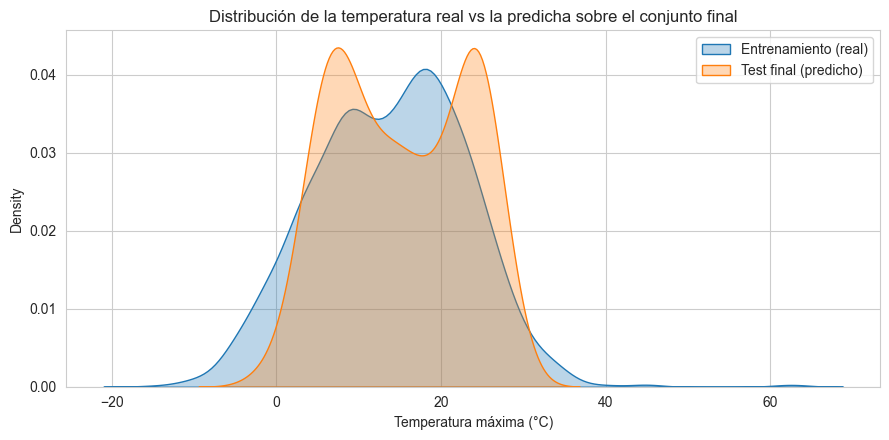

In [86]:
# Comparación entre la distribución predicha y la observada en entrenamiento
plt.figure(figsize=(9, 4.5))

sns.kdeplot(y, label="Entrenamiento (real)", fill=True, alpha=0.3)
sns.kdeplot(predicciones_finales, label="Test final (predicho)", fill=True, alpha=0.3)

plt.xlabel("Temperatura máxima (°C)")
plt.title("Distribución de la temperatura real vs la predicha sobre el conjunto final")
plt.legend()
plt.tight_layout()
plt.show()

In [87]:
# Exportación: se toma como base el mismo archivo entregado
final_output = final_test.copy()
final_output[TARGET] = predicciones_finales

OUTPUT_PATH = RESULTS_DIR / "Datos Test Lab 1.csv"
final_output.to_csv(OUTPUT_PATH, index=False)

print("Archivo guardado en:", OUTPUT_PATH)
print("Columnas exportadas:", final_output.shape[1])
final_output.head()

Archivo guardado en: resultados/Datos Test Lab 1.csv
Columnas exportadas: 27


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,viento_max,viento_desv,rafaga_media,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,01.01.2016,998.9860,995.57,1000.60,1.1082,96.1493,90.8,98.7,2.0034,0.9649,0.18,3.13,0.5552,1.7068,0.40,5.17,0.8415,-0.8328,0.0927,173.6501,144,2016,1,invierno,January,S,5.590943
1,02.01.2016,991.4241,989.27,995.51,1.9413,92.3236,85.8,96.8,2.6562,1.9886,0.21,4.01,1.0960,2.8128,0.52,5.37,1.3604,1.1161,0.6688,30.9301,144,2016,2,invierno,January,NE,1.665231
2,03.01.2016,984.0232,974.12,989.39,4.5841,83.6056,73.9,94.7,6.9967,2.4992,0.60,4.46,0.8034,3.9316,1.28,6.49,1.2558,-0.7923,1.2638,122.0847,144,2016,3,invierno,January,SE,5.053658
3,04.01.2016,968.2449,966.52,974.02,1.9034,85.4688,75.5,93.8,5.8148,2.0932,0.25,4.06,0.8433,3.4434,0.48,6.25,1.4544,-1.6217,0.7020,156.5944,144,2016,4,invierno,January,SE,4.713993
4,05.01.2016,970.0099,967.85,972.90,1.6668,94.3521,92.0,96.8,1.4253,1.8380,0.45,3.21,0.6245,2.4610,0.80,4.41,0.7284,1.6549,0.7109,23.2458,144,2016,5,invierno,January,NE,-1.443585


### Verificación de las predicciones

Las 364 predicciones se distribuyen entre **−2.07 °C y 29.44 °C**, con una media de
**15.23 °C**. El rango y la forma de la distribución son consistentes con las
temperaturas observadas en el conjunto de entrenamiento, aunque la curva predicha es
más concentrada: esto es esperable, ya que la regresión lineal predice el valor
esperado y no reproduce los valores extremos de la distribución real.

El archivo exportado conserva todas las columnas originales de `Datos Test Lab 1.csv`
y agrega la columna `temp_max_manana` con la predicción de cada día.

# 13. Conclusiones

**1. Qué tan bien funcionó el modelo.** El modelo final predice la temperatura máxima
del día siguiente con un **RMSE de 4.9973 °C** y un **MAE de 3.6285 °C** sobre datos
no vistos, explicando el **70.8% de la variabilidad** (R² = 0.7084). Las métricas de
entrenamiento y prueba son muy cercanas (RMSE 4.8208 vs 4.9973), por lo que el modelo
generaliza sin sobreajuste. Para un modelo lineal que solo dispone de la información
meteorológica del día anterior y sin ningún dato de temperatura previa, es un
resultado razonable.

**2. Qué estrategia mejoró más los resultados.** La **ingeniería de características**,
sin cambiar de algoritmo. Pasar de RMSE 6.9016 a 4.9973 (−27.6%) se explica
fundamentalmente por la **representación cíclica del día del año**: el Modelo 1
recibía `dia_del_anio` como una recta creciente de 1 a 365, forzando a la regresión a
suponer que la temperatura sube o baja de forma constante durante todo el año.
Codificarla como seno y coseno permitió representar el ciclo estacional real. El test
de Rainbow de la sección 9.5 confirma este razonamiento: con las variables cíclicas,
el supuesto de linealidad se cumple (p = 0.7058).

Una segunda decisión con impacto desproporcionado fue la **limpieza de valores no
físicos** de la sección 4.6. Su efecto sobre las métricas fue pequeño (RMSE 5.0141 →
4.9973), pero decisivo para la interpretación: un único registro corrupto generaba un
VIF de ≈ 1970 y coeficientes de ±28.7 que dominaban por completo la tabla de
importancia de variables.

**3. Cuáles variables fueron más relevantes.** En orden: el **componente estacional**
(`dia_sin`, `dia_cos`, amplitud combinada ≈ 6.70 °C, con máximo alrededor del 20 de
julio), la **dirección del viento** (`viento_norte` −1.6009, `direccion_sin` +1.1798),
la **tendencia interanual** (`anio` +0.7407), la **presión media** (+0.6830) y la
**humedad media** (−0.5703). Todos los signos son coherentes con la meteorología del
hemisferio norte, lo cual es una señal de que el modelo aprendió estructura real y no
artefactos de los datos.

**4. Limitaciones del análisis.**

- Los residuales **no son normales** (Shapiro-Wilk p ≈ 2.6 × 10⁻³⁴, asimetría 1.88)
  ni **homocedásticos** (Breusch-Pagan p ≈ 1.2 × 10⁻⁴), por lo que el modelo sirve
  para predecir y para ordenar variables por importancia, pero no admite inferencia
  estadística formal sobre sus coeficientes.
- El error **no es uniforme a lo largo del año**: la dispersión de los residuales es
  mayor en invierno y en las transiciones estacionales que en verano.
- La partición aleatoria exigida por el enunciado (`random_state=42`) **mezcla los
  días** de una serie de tiempo. Como días consecutivos son muy parecidos entre sí,
  es probable que el rendimiento sobre test sea algo optimista frente al que se
  obtendría prediciendo un periodo futuro completo. Una validación cronológica sería
  más exigente y más cercana al uso real.
- La colinealidad **moderada** en el bloque de variabilidad del viento
  (VIF ≈ 10.7) impide separar los efectos individuales de esas variables.
- El modelo no dispone de la temperatura de días anteriores, que es el predictor más
  natural de la temperatura de mañana y que probablemente explicaría buena parte del
  29% de variabilidad no capturada.

**5. Cómo podría usarse este conocimiento en AlpesPlanck.** El modelo entrega una
línea base cuantitativa y explicable para anticipar días de calor. Para el objetivo de
mitigación de incendios forestales, el hallazgo operativo es que el riesgo se
concentra en la combinación *base estacional alta (mayo–agosto) + alta presión + baja
humedad + viento con componente sur*, y que existe una tendencia interanual creciente
que obliga a **recalibrar periódicamente los umbrales de alerta**: los umbrales
calculados con datos de 2003 subestiman las temperaturas actuales.

Como siguientes pasos naturales, el equipo debería incorporar variables rezagadas de
temperatura, evaluar modelos regularizados (Ridge, Lasso) que manejan mejor la
colinealidad detectada, y validar el modelo con un esquema cronológico antes de
llevarlo a operación.

# 14. Uso de herramientas de IA generativa

## Declaración del uso

**Herramientas utilizadas:** ChatGPT y Claude.

Durante el desarrollo del laboratorio se utilizó ChatGPT como herramienta de apoyo. Su uso estuvo enfocado principalmente en la organización del trabajo, solución de problemas técnicos y orientación conceptual. La herramienta no se utilizó para realizar automáticamente todo el laboratorio ni para reemplazar el análisis de los resultados obtenidos.

Los principales usos fueron:

- Crear una **estructura base del archivo `.ipynb`**, con secciones de código y Markdown que sirvieran como guía para saber dónde desarrollar cada parte del laboratorio.
- Ayudar a dar **formato y organización a las celdas Markdown**, incluyendo títulos, subtítulos, resaltado de conceptos importantes y organización de explicaciones.
- Resolver problemas técnicos relacionados con la creación, activación y configuración del **entorno virtual `.venv`** y el kernel de Python en VS Code.
- Apoyar la identificación y explicación de algunos errores de ejecución durante el desarrollo del notebook.
- Proponer una **idea conceptual para la segunda estrategia de regresión lineal**, basada en ingeniería de características, que posteriormente fue revisada, implementada y evaluada con los datos del laboratorio.
- Generar la **exportación del notebook a formato `.html`** solicitada como entregable. Para esta tarea se utilizó Claude, pasándole como contexto el notebook completo.

## Ejemplos de prompts utilizados

Algunos prompts representativos utilizados durante el desarrollo fueron:

1. **Creación de la estructura del notebook**

   > "Leyendo el enunciado del laboratorio, dame un archivo `.ipynb` base con la estructura necesaria para desarrollar cada punto. Incluye espacios para código y explicaciones, pero no hagas completamente el laboratorio."

2. **Organización de Markdown**

   > "Organízame este texto para que quede bien presentado en Markdown dentro de un notebook, usando títulos, subtítulos y resaltando los conceptos importantes."

3. **Configuración del entorno virtual**

   > "Como creo y activo un entorno virtual `.venv` para este proyecto en VS Code y cómo hago para que el notebook use ese entorno?"

4. **Solución de errores**

   > "Me aparece este error al ejecutar el pipeline. Explícame qué significa y qué parte del código debería revisar."

5. **Orientación para un segundo modelo**

   > "Dame una idea general para construir un segundo modelo de regresión lineal usando una estrategia de preparación o ingeniería de características diferente al modelo base."

6. **Exportación del notebook a HTML** (Claude, con el notebook completo como contexto)

   > "Toma este notebook completo y genera el archivo `.html` correspondiente, conservando las salidas de todas las celdas."

## Análisis crítico del uso de la herramienta

ChatGPT fue útil principalmente para organizar el proceso y explicar conceptos o errores de manera rápida. La estructura inicial del notebook facilitó la división del laboratorio en etapas y permitió tener claro dónde incluir el análisis exploratorio, preparación de datos, construcción de modelos y evaluación.

Sin embargo, las respuestas de la herramienta no se utilizaron directamente sin revisión. Algunas sugerencias tuvieron que ser adaptadas a las variables reales del conjunto de datos, al diccionario de datos y a los resultados obtenidos durante el EDA. También fue necesario comprobar que las estrategias propuestas fueran consistentes con las prácticas y conceptos vistos en clase.

Por ejemplo, la propuesta conceptual para el Modelo 2 fue tomada únicamente como una idea inicial. Su implementación se realizó sobre los datos del laboratorio y su utilidad se verificó comparando las métricas obtenidas con las del Modelo 1.

## Aportes propios

Las decisiones finales del laboratorio fueron realizadas por los integrantes del grupo a partir de los datos y los conceptos vistos en clase.

Entre los aportes propios se encuentran:

- Ejecución e interpretación del análisis exploratorio de datos.
- Identificación de problemas de completitud, unicidad, consistencia y validez.
- Decisión sobre las estrategias utilizadas para limpiar y preparar los datos.
- Revisión y adaptación del código sugerido a las variables reales del dataset.
- Ejecución de los modelos y análisis de las métricas obtenidas.
- Comparación de los resultados entre las diferentes estrategias.
- Redacción y revisión final de las conclusiones del laboratorio.

Por lo tanto, la herramienta de IA se utilizó principalmente como apoyo técnico, conceptual y de organización, mientras que la ejecución, validación de resultados y decisiones finales fueron realizadas por el grupo.